# Install The LIbraries

In [1]:
!pip install statsmodels pmdarima xgboost openpyxl -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.1 MB/s eta 0:00:00


# Import file from laptop

In [2]:
from google.colab import files
uploaded = files.upload()
# Select: Internship Updated Datasheet.xlsx

Saving Internship Updated Datasheet.xlsx to Internship Updated Datasheet.xlsx


# Data Loading from provided file

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'      : 'DejaVu Serif',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
    'legend.fontsize'  : 10,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 200,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
})

C = {
    'sarima' : '#2166ac',
    'xgb'    : '#d6604d',
    'hybrid' : '#1a9641',
    'actual' : '#222222',
    'clim'   : '#7f7f7f',
    'monsoon': '#4575b4'
}

FILE = "Internship Updated Datasheet.xlsx"
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

# ── Load all sheets
monthly   = pd.read_excel(FILE, sheet_name='Monthly_Data')
annual    = pd.read_excel(FILE, sheet_name='Annual_Summary')
clim_df   = pd.read_excel(FILE, sheet_name='Climatology')
wide_df   = pd.read_excel(FILE, sheet_name='Year_x_Month')
enso_iod  = pd.read_excel(FILE, sheet_name='ENSO_IOD_Index')
jjas_df   = pd.read_excel(FILE, sheet_name='JJAS_Rainfall')

# Clean column names
monthly.columns   = ['Year','Month_No','Month','Season',
                      'Rainfall_mm','Log_Rain','ENSO','IOD','Split']
annual.columns    = ['Year','Annual_mm','JJAS_mm',
                      'ENSO','IOD','Split']
clim_df.columns   = ['Month_No','Month','Mean','Std',
                      'Min','Max','CV']
enso_iod.columns  = ['Year','ENSO','IOD','Phase']
jjas_df.columns   = ['Year','Month','Rainfall_mm','JJAS_Total']

# ── Create datetime index
monthly['date'] = pd.to_datetime(
    monthly['Year'].astype(str) + '-' +
    monthly['Month_No'].astype(str).str.zfill(2) + '-01'
)
monthly = monthly.set_index('date')

series     = monthly['Rainfall_mm']
log_series = monthly['Log_Rain']

TRAIN_END  = '2018-12'
TEST_START = '2019-01'
train      = log_series[:TRAIN_END]
test       = log_series[TEST_START:]
train_raw  = series[:TRAIN_END]
test_raw   = series[TEST_START:]

print(f"Loaded successfully")
print(f"Total months : {len(monthly)}")
print(f"Train        : {len(train)} months")
print(f"Test         : {len(test)} months")
print(f"Sheets       : Monthly_Data, Annual_Summary, Climatology,")
print(f"               Year_x_Month, ENSO_IOD_Index, JJAS_Rainfall")

Loaded successfully
Total months : 516
Train        : 468 months
Test         : 48 months
Sheets       : Monthly_Data, Annual_Summary, Climatology,
               Year_x_Month, ENSO_IOD_Index, JJAS_Rainfall


# Figure 1(a) - Time Series

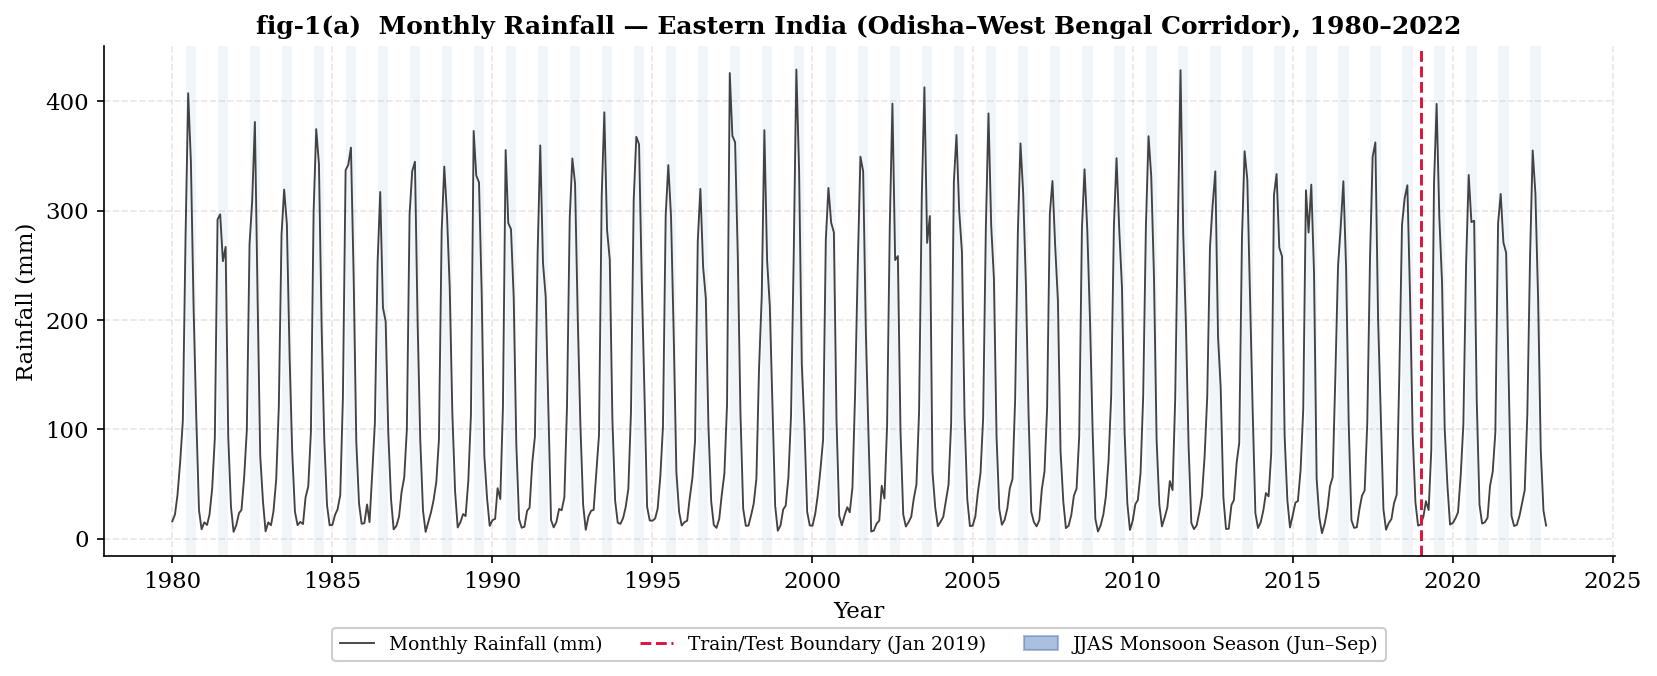

Figure 1a saved


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'      : 'DejaVu Serif',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
    'legend.fontsize'  : 10,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 200,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
})

C = {
    'sarima' : '#2166ac',
    'xgb'    : '#d6604d',
    'hybrid' : '#1a9641',
    'actual' : '#222222',
    'clim'   : '#7f7f7f',
    'monsoon': '#4575b4'
}

FILE = "Internship Updated Datasheet.xlsx"
TEST_START = '2019-01'

# ── Load data
monthly = pd.read_excel(FILE, sheet_name='Monthly_Data')
monthly.columns = ['Year','Month_No','Month','Season',
                   'Rainfall_mm','Log_Rain',
                   'ENSO','IOD','Split']
monthly['date'] = pd.to_datetime(
    monthly['Year'].astype(str) + '-' +
    monthly['Month_No'].astype(str).str.zfill(2) + '-01'
)
monthly = monthly.set_index('date')
series  = monthly['Rainfall_mm']

# ── Plot
fig, ax = plt.subplots(figsize=(13,5))

# Main rainfall line
line_rain, = ax.plot(
    series.index, series.values,
    color=C['actual'], lw=0.9,
    alpha=0.85, label='Monthly Rainfall (mm)'
)

# Shade JJAS every year
for yr in range(1980, 2023):
    ax.axvspan(
        pd.Timestamp(f'{yr}-06-01'),
        pd.Timestamp(f'{yr}-09-30'),
        color=C['monsoon'], alpha=0.07, lw=0
    )

# Train test boundary line
line_split = ax.axvline(
    pd.Timestamp(TEST_START),
    color='crimson', lw=1.4,
    ls='--', label='Train/Test Boundary (Jan 2019)'
)

# ── Axis labels and title
ax.set_ylabel('Rainfall (mm)')
ax.set_xlabel('Year')
ax.set_title(
    'fig-1(a)  Monthly Rainfall — Eastern India '
    '(Odisha–West Bengal Corridor), 1980–2022',
    fontweight='bold'
)

# ── Legend under the graph
patch = mpatches.Patch(
    color=C['monsoon'], alpha=0.45,
    label='JJAS Monsoon Season (Jun–Sep)'
)

ax.legend(
    handles=[line_rain, line_split, patch],
    framealpha=0.95,
    fontsize=9,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.14),  # below x-axis
    ncol=3,                        # all 3 side by side
    borderaxespad=0,
    handlelength=1.8
)

# Make room at the bottom for the legend
plt.subplots_adjust(bottom=0.20)

plt.savefig('fig1a_timeseries.png',
            dpi=200,
            bbox_inches='tight')
plt.show()
print("Figure 1a saved")

# Figure 1(b) - Climatology

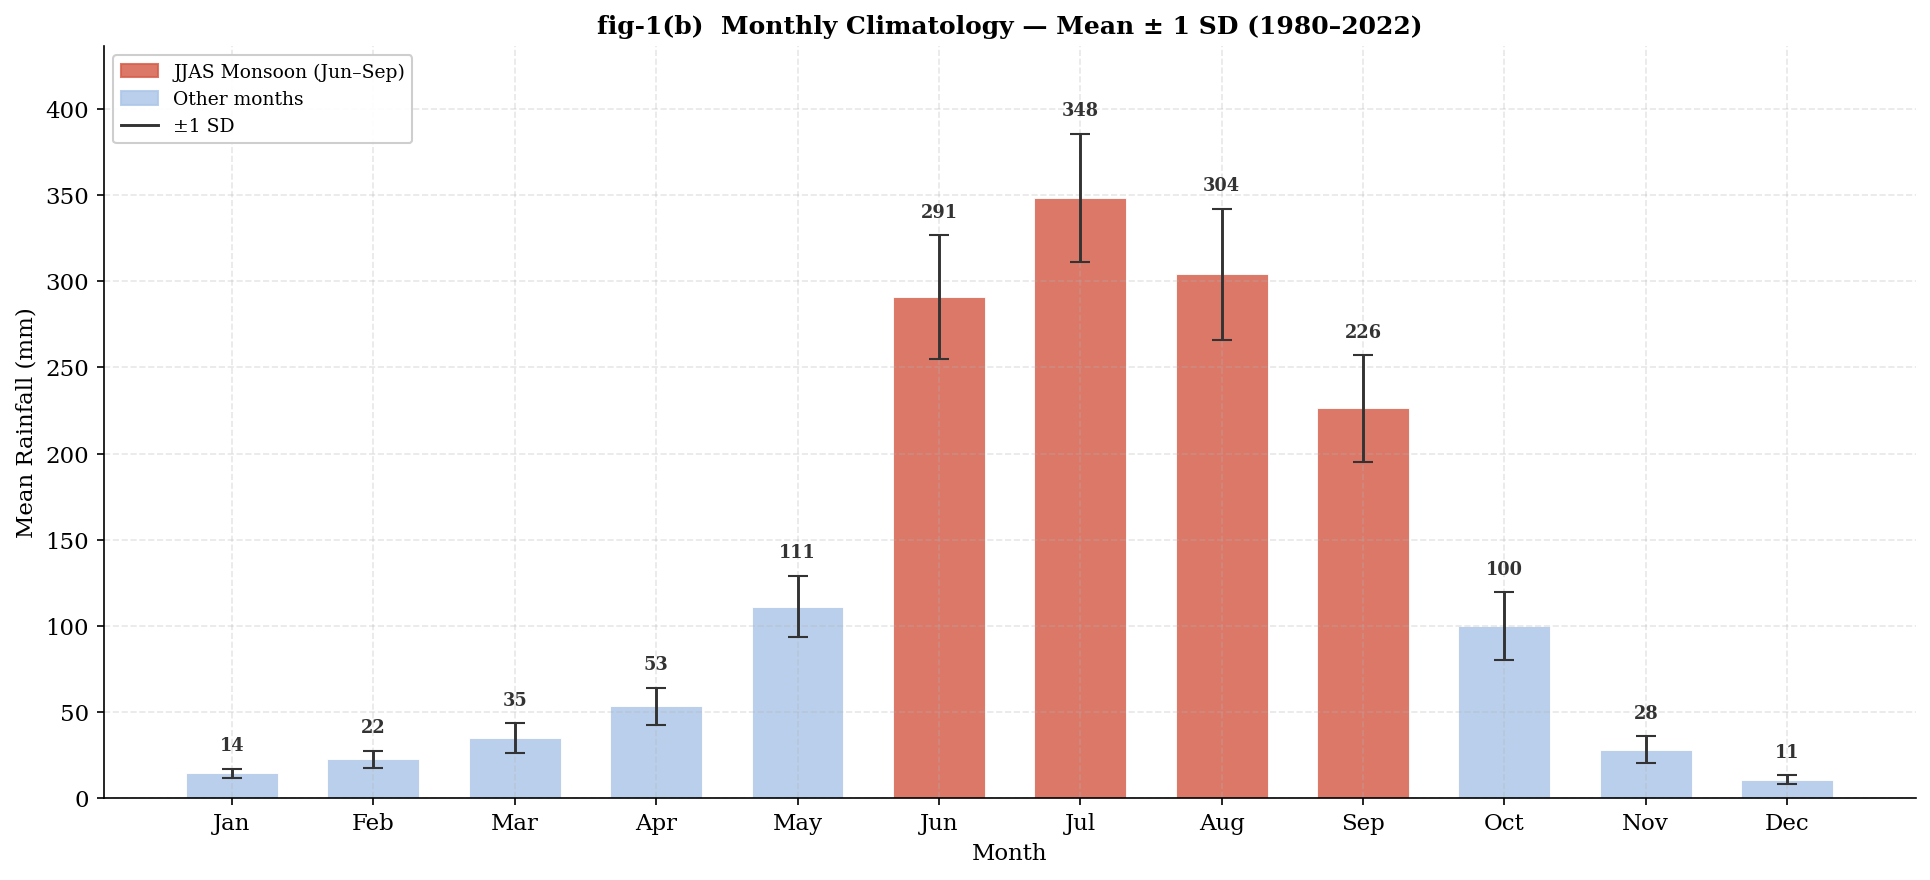

Figure 1b saved


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'      : 'DejaVu Serif',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
    'legend.fontsize'  : 10,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 200,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
})

FILE = "Internship Updated Datasheet.xlsx"

# ── Load Climatology sheet
clim_df = pd.read_excel(FILE, sheet_name='Climatology')
clim_df.columns = ['Month_No','Month','Mean',
                    'Std','Min','Max','CV']

# Filter clim_df to exclude the summary row at the end
clim_df_plot = clim_df.iloc[:12]

# ── Plot
fig, ax = plt.subplots(figsize=(13, 6))

# Bar colors
bcolors = [
    '#d6604d' if i in [5, 6, 7, 8]
    else '#aec7e8'
    for i in range(12)
]

# Draw bars
bars = ax.bar(
    clim_df_plot['Month'],
    clim_df_plot['Mean'],
    color=bcolors,
    alpha=0.85,
    edgecolor='white',
    lw=0.5,
    width=0.65
)

# Error bars ±1 SD
ax.errorbar(
    clim_df_plot['Month'],
    clim_df_plot['Mean'],
    yerr=clim_df_plot['Std'],
    fmt='none',
    color='#333333',
    capsize=5,
    lw=1.4,
    label='±1 SD',
    zorder=5
)

# ── Value labels — sit above the error bar
for bar, val, sd in zip(bars,
                         clim_df_plot['Mean'],
                         clim_df_plot['Std']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + sd + 8,  # above error bar
        f'{val:.0f}',
        ha='center',
        va='bottom',
        fontsize=8.5,
        color='#333333',
        fontweight='bold'
    )

# ── Axis labels and title
ax.set_ylabel('Mean Rainfall (mm)')
ax.set_xlabel('Month')
ax.set_title(
    'fig-1(b)  Monthly Climatology — Mean ± 1 SD (1980–2022)',
    fontweight='bold'
)

# ── Y axis limit — give room for labels at top
ax.set_ylim(0, clim_df_plot['Mean'].max()
               + clim_df_plot['Std'].max() + 50)

# ── Legend
p1 = mpatches.Patch(color='#d6604d', alpha=0.85,
                     label='JJAS Monsoon (Jun–Sep)')
p2 = mpatches.Patch(color='#aec7e8', alpha=0.85,
                     label='Other months')
sd_line = plt.Line2D([0], [0],
                      color='#333333',
                      lw=1.4,
                      label='±1 SD')
ax.legend(
    handles=[p1, p2, sd_line],
    framealpha=0.95,
    fontsize=9,
    loc='upper left'
)

plt.tight_layout()
plt.savefig('fig1b_climatology.png',
            dpi=200,
            bbox_inches='tight')
plt.show()
print("Figure 1b saved")

# Figure 1(c) - JJAS Time Series Bar Chart

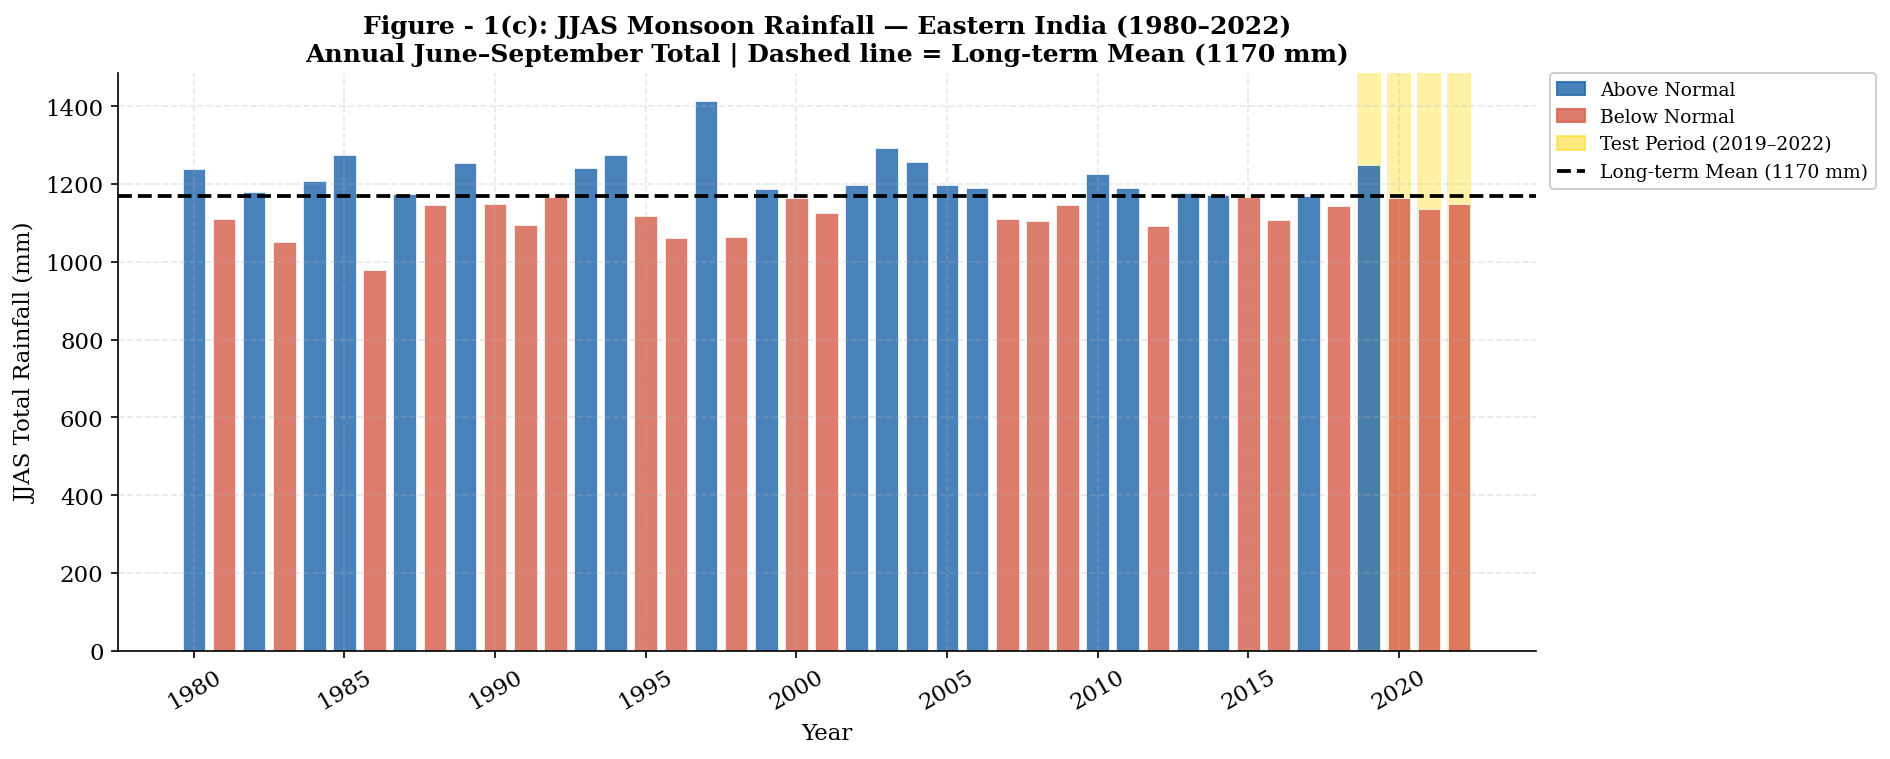

JJAS Figure saved


In [6]:
# ── Load data
FILE   = "Internship Updated Datasheet.xlsx"
annual = pd.read_excel(FILE, sheet_name='Annual_Summary').iloc[:-1]
annual.columns = ['Year','Annual_mm','JJAS_mm',
                   'ENSO','IOD','Split']

# ── Calculate mean and anomaly
mean_jjas         = annual['JJAS_mm'].mean()
annual['Anomaly'] = annual['JJAS_mm'].apply(
    lambda x: 'Above Normal' if x >= mean_jjas
              else 'Below Normal'
)

# ── Plot
fig, ax = plt.subplots(figsize=(14, 5))

# Bar colors
colors = [
    '#2166ac' if a == 'Above Normal'
    else '#d6604d'
    for a in annual['Anomaly']
]

ax.bar(
    annual['Year'],
    annual['JJAS_mm'],
    color=colors,
    alpha=0.82,
    edgecolor='white',
    lw=0.4,
    width=0.75
)

# Long-term mean line
ax.axhline(
    mean_jjas,
    color='black',
    lw=1.8,
    ls='--',
    zorder=5
)

# Shade test period years
test_years = annual[annual['Split'] == 'Test']['Year']
for yr in test_years:
    ax.axvspan(yr - 0.4, yr + 0.4,
               color='gold', alpha=0.35,
               lw=0, zorder=0)

# Axis labels
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('JJAS Total Rainfall (mm)', fontsize=11)
ax.set_title(
    'Figure - 1(c): JJAS Monsoon Rainfall — Eastern India (1980–2022)\n'
    'Annual June–September Total | '
    'Dashed line = Long-term Mean '
    f'({mean_jjas:.0f} mm)',
    fontweight='bold', fontsize=12
)
ax.set_xticks(range(1980, 2023, 5))
ax.tick_params(axis='x', rotation=30)

# ── Legend — completely outside the plot on the right
p1 = mpatches.Patch(color='#2166ac', alpha=0.82,
                     label='Above Normal')
p2 = mpatches.Patch(color='#d6604d', alpha=0.82,
                     label='Below Normal')
p3 = mpatches.Patch(color='gold',    alpha=0.5,
                     label='Test Period (2019–2022)')
p4 = plt.Line2D([0], [0],
                 color='black', lw=1.8, ls='--',
                 label=f'Long-term Mean ({mean_jjas:.0f} mm)')

ax.legend(
    handles=[p1, p2, p3, p4],
    framealpha=0.95,
    fontsize=9,
    loc='upper left',
    bbox_to_anchor=(1.01, 1),   # push outside right
    borderaxespad=0,
    handlelength=1.5
)

# Make room for legend on the right
plt.subplots_adjust(right=0.80)

plt.savefig('fig_jjas_timeseries.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("JJAS Figure saved")

# Data set making for Observed = Trend + Seasonal + Residual

In [7]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

FILE = "Internship Updated Datasheet.xlsx"

# Load raw rainfall
monthly = pd.read_excel(FILE, sheet_name='Monthly_Data')
monthly.columns = ['Year','Month_No','Month','Season',
                   'Rainfall_mm','Log_Rain',
                   'ENSO','IOD','Split']
monthly['date'] = pd.to_datetime(
    monthly['Year'].astype(str) + '-' +
    monthly['Month_No'].astype(str).str.zfill(2) + '-01'
)
monthly = monthly.set_index('date')
series  = monthly['Rainfall_mm']   # raw mm — NOT log

# ── Decompose
decomp = seasonal_decompose(
    series,
    model='additive',
    period=12
)

# ── Build dataset of all 4 components
decomp_df = pd.DataFrame({
    'Year'        : monthly['Year'],
    'Month_No'    : monthly['Month_No'],
    'Month'       : monthly['Month'],
    'Observed_mm' : decomp.observed,
    'Trend_mm'    : decomp.trend,
    'Seasonal_mm' : decomp.seasonal,
    'Residual_mm' : decomp.resid
})

# Reset index to show date as column
decomp_df = decomp_df.reset_index()
decomp_df.rename(columns={'date':'Date'}, inplace=True)

# ── Check
print(decomp_df.head(24).to_string())
print(f"\nTotal rows : {len(decomp_df)}")
print(f"NaN in Trend   : {decomp_df['Trend_mm'].isna().sum()}")
print(f"NaN in Residual: {decomp_df['Residual_mm'].isna().sum()}")

# ── Verify the formula for one row
row = decomp_df.dropna().iloc[0]
check = row['Trend_mm'] + row['Seasonal_mm'] + row['Residual_mm']
print(f"\nVerification check:")
print(f"Observed              = {row['Observed_mm']:.2f}")
print(f"Trend+Seasonal+Resid  = {check:.2f}")

# ── Save to Excel
decomp_df.to_excel('isi_internship_decomposition_dataset.xlsx', index=False)
print("\nSaved to isi_internship_decomposition_dataset.xlsx")

         Date  Year  Month_No Month  Observed_mm    Trend_mm  Seasonal_mm  Residual_mm
0  1980-01-01  1980         1   Jan        15.81         NaN  -114.444826          NaN
1  1980-02-01  1980         2   Feb        22.06         NaN  -106.137296          NaN
2  1980-03-01  1980         3   Mar        40.07         NaN   -93.758913          NaN
3  1980-04-01  1980         4   Apr        70.63         NaN   -75.714181          NaN
4  1980-05-01  1980         5   May       107.91         NaN   -17.283238          NaN
5  1980-06-01  1980         6   Jun       276.85         NaN   162.826623          NaN
6  1980-07-01  1980         7   Jul       407.31  136.832083   219.487833    50.990083
7  1980-08-01  1980         8   Aug       344.53  136.402917   174.957784    33.169300
8  1980-09-01  1980         9   Sep       210.13  135.250000    97.544530   -22.664530
9  1980-10-01  1980        10   Oct       112.11  133.472500   -28.610917     7.248417
10 1980-11-01  1980        11   Nov        

# Figure 2 - graph of observe, trend, seasonal, residual

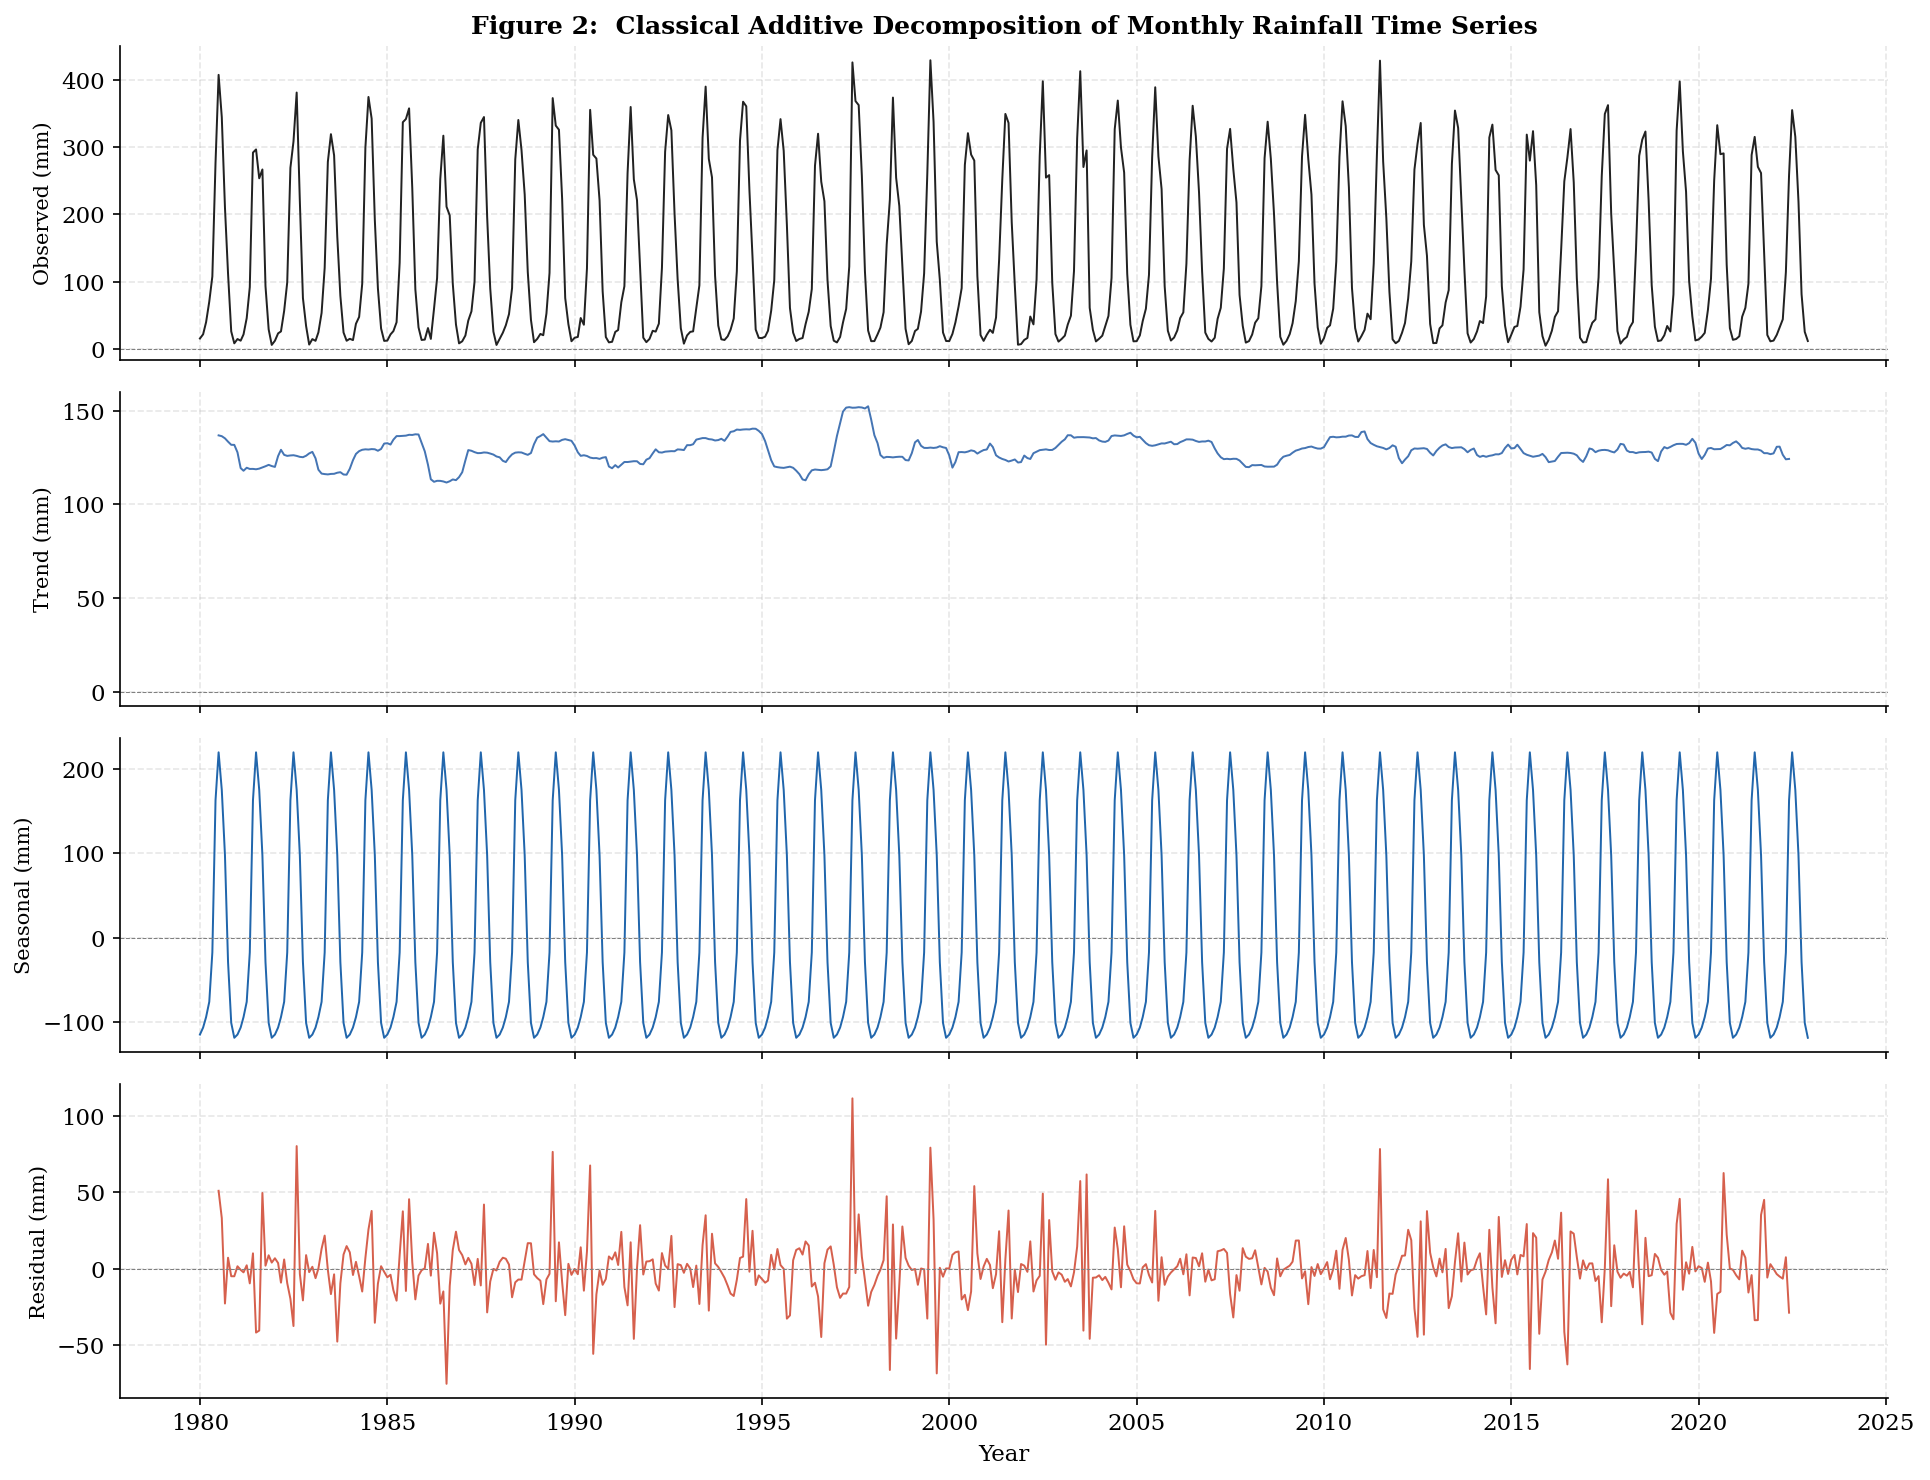

Figure 2 saved


In [8]:
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

components = [
    ('Observed (mm)',  'Observed_mm',  '#222222'),
    ('Trend (mm)',     'Trend_mm',     '#4575b4'),
    ('Seasonal (mm)',  'Seasonal_mm',  '#2166ac'),
    ('Residual (mm)',  'Residual_mm',  '#d6604d'),
]

for ax, (label, col_name, color) in zip(axes, components):
    ax.plot(
        decomp_df['Date'],
        decomp_df[col_name],
        color=color, lw=0.95
    )
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_ylabel(label, fontsize=10)

axes[0].set_title(
    'Figure 2:  Classical Additive Decomposition '
    'of Monthly Rainfall Time Series',
    fontweight='bold', fontsize=12
)
axes[-1].set_xlabel('Year')

plt.tight_layout()
plt.savefig('fig2_decomp.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 2 saved")

# Table 1 - ADF/KPSS

In [9]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

FILE = "Internship Updated Datasheet.xlsx"

# ── Load raw rainfall
monthly = pd.read_excel(FILE, sheet_name='Monthly_Data')
monthly.columns = ['Year','Month_No','Month','Season',
                   'Rainfall_mm','Log_Rain',
                   'ENSO','IOD','Split']

# Set datetime index
monthly['date'] = pd.to_datetime(
    monthly['Year'].astype(str) + '-' +
    monthly['Month_No'].astype(str).str.zfill(2) + '-01'
)
monthly = monthly.set_index('date')

# ── Raw series — no transformation
raw_series = monthly['Rainfall_mm']

# ── Log transformed series
log_series = monthly['Log_Rain']

# ══════════════════════════════════════
# ADF TEST
# ══════════════════════════════════════
adf_raw = adfuller(raw_series, autolag='AIC')
adf_log = adfuller(log_series, autolag='AIC')

print("=" * 45)
print("ADF TEST RESULTS")
print("=" * 45)
print(f"\nRaw Rainfall:")
print(f"  ADF Statistic : {adf_raw[0]:.6f}")
print(f"  p-value       : {adf_raw[1]:.6f}")
print(f"  Decision      : {'Stationary' if adf_raw[1] < 0.05 else 'Non-Stationary'}")

print(f"\nLog Transformed:")
print(f"  ADF Statistic : {adf_log[0]:.6f}")
print(f"  p-value       : {adf_log[1]:.6f}")
print(f"  Decision      : {'Stationary' if adf_log[1] < 0.05 else 'Non-Stationary'}")

# ══════════════════════════════════════
# KPSS TEST
# ══════════════════════════════════════
kpss_raw = kpss(raw_series, regression='c', nlags='auto')
kpss_log = kpss(log_series, regression='c', nlags='auto')

print("\n" + "=" * 45)
print("KPSS TEST RESULTS")
print("=" * 45)
print(f"\nRaw Rainfall:")
print(f"  KPSS Statistic: {kpss_raw[0]:.6f}")
print(f"  p-value       : {kpss_raw[1]:.6f}")
print(f"  Decision      : {'Stationary' if kpss_raw[1] > 0.05 else 'Non-Stationary'}")

print(f"\nLog Transformed:")
print(f"  KPSS Statistic: {kpss_log[0]:.6f}")
print(f"  p-value       : {kpss_log[1]:.6f}")
print(f"  Decision      : {'Stationary' if kpss_log[1] > 0.05 else 'Non-Stationary'}")

# ══════════════════════════════════════
# SUMMARY TABLE
# ══════════════════════════════════════
print("\n" + "=" * 55)
print("SUMMARY TABLE — Copy these into your paper Table 1")
print("=" * 55)
print(f"{'Test':<30} {'Series':<18} {'Statistic':<12} {'p-value':<12} {'Decision'}")
print("-" * 55)
print(f"{'ADF':<30} {'Raw':<18} {adf_raw[0]:<12.4f} {adf_raw[1]:<12.4f} {'Stationary' if adf_raw[1]<0.05 else 'Non-Stationary'}")
print(f"{'ADF':<30} {'Log-transformed':<18} {adf_log[0]:<12.4f} {adf_log[1]:<12.4f} {'Stationary' if adf_log[1]<0.05 else 'Non-Stationary'}")
print(f"{'KPSS':<30} {'Raw':<18} {kpss_raw[0]:<12.4f} {kpss_raw[1]:<12.4f} {'Stationary' if kpss_raw[1]>0.05 else 'Non-Stationary'}")
print(f"{'KPSS':<30} {'Log-transformed':<18} {kpss_log[0]:<12.4f} {kpss_log[1]:<12.4f} {'Stationary' if kpss_log[1]>0.05 else 'Non-Stationary'}")

ADF TEST RESULTS

Raw Rainfall:
  ADF Statistic : -6.620097
  p-value       : 0.000000
  Decision      : Stationary

Log Transformed:
  ADF Statistic : -5.438149
  p-value       : 0.000003
  Decision      : Stationary

KPSS TEST RESULTS

Raw Rainfall:
  KPSS Statistic: 0.010935
  p-value       : 0.100000
  Decision      : Stationary

Log Transformed:
  KPSS Statistic: 0.009387
  p-value       : 0.100000
  Decision      : Stationary

SUMMARY TABLE — Copy these into your paper Table 1
Test                           Series             Statistic    p-value      Decision
-------------------------------------------------------
ADF                            Raw                -6.6201      0.0000       Stationary
ADF                            Log-transformed    -5.4381      0.0000       Stationary
KPSS                           Raw                0.0109       0.1000       Stationary
KPSS                           Log-transformed    0.0094       0.1000       Stationary




*   In ADF, KPSS test... it is stationary.... so **d=0**



# Figure 3 - ACF, PACF plot

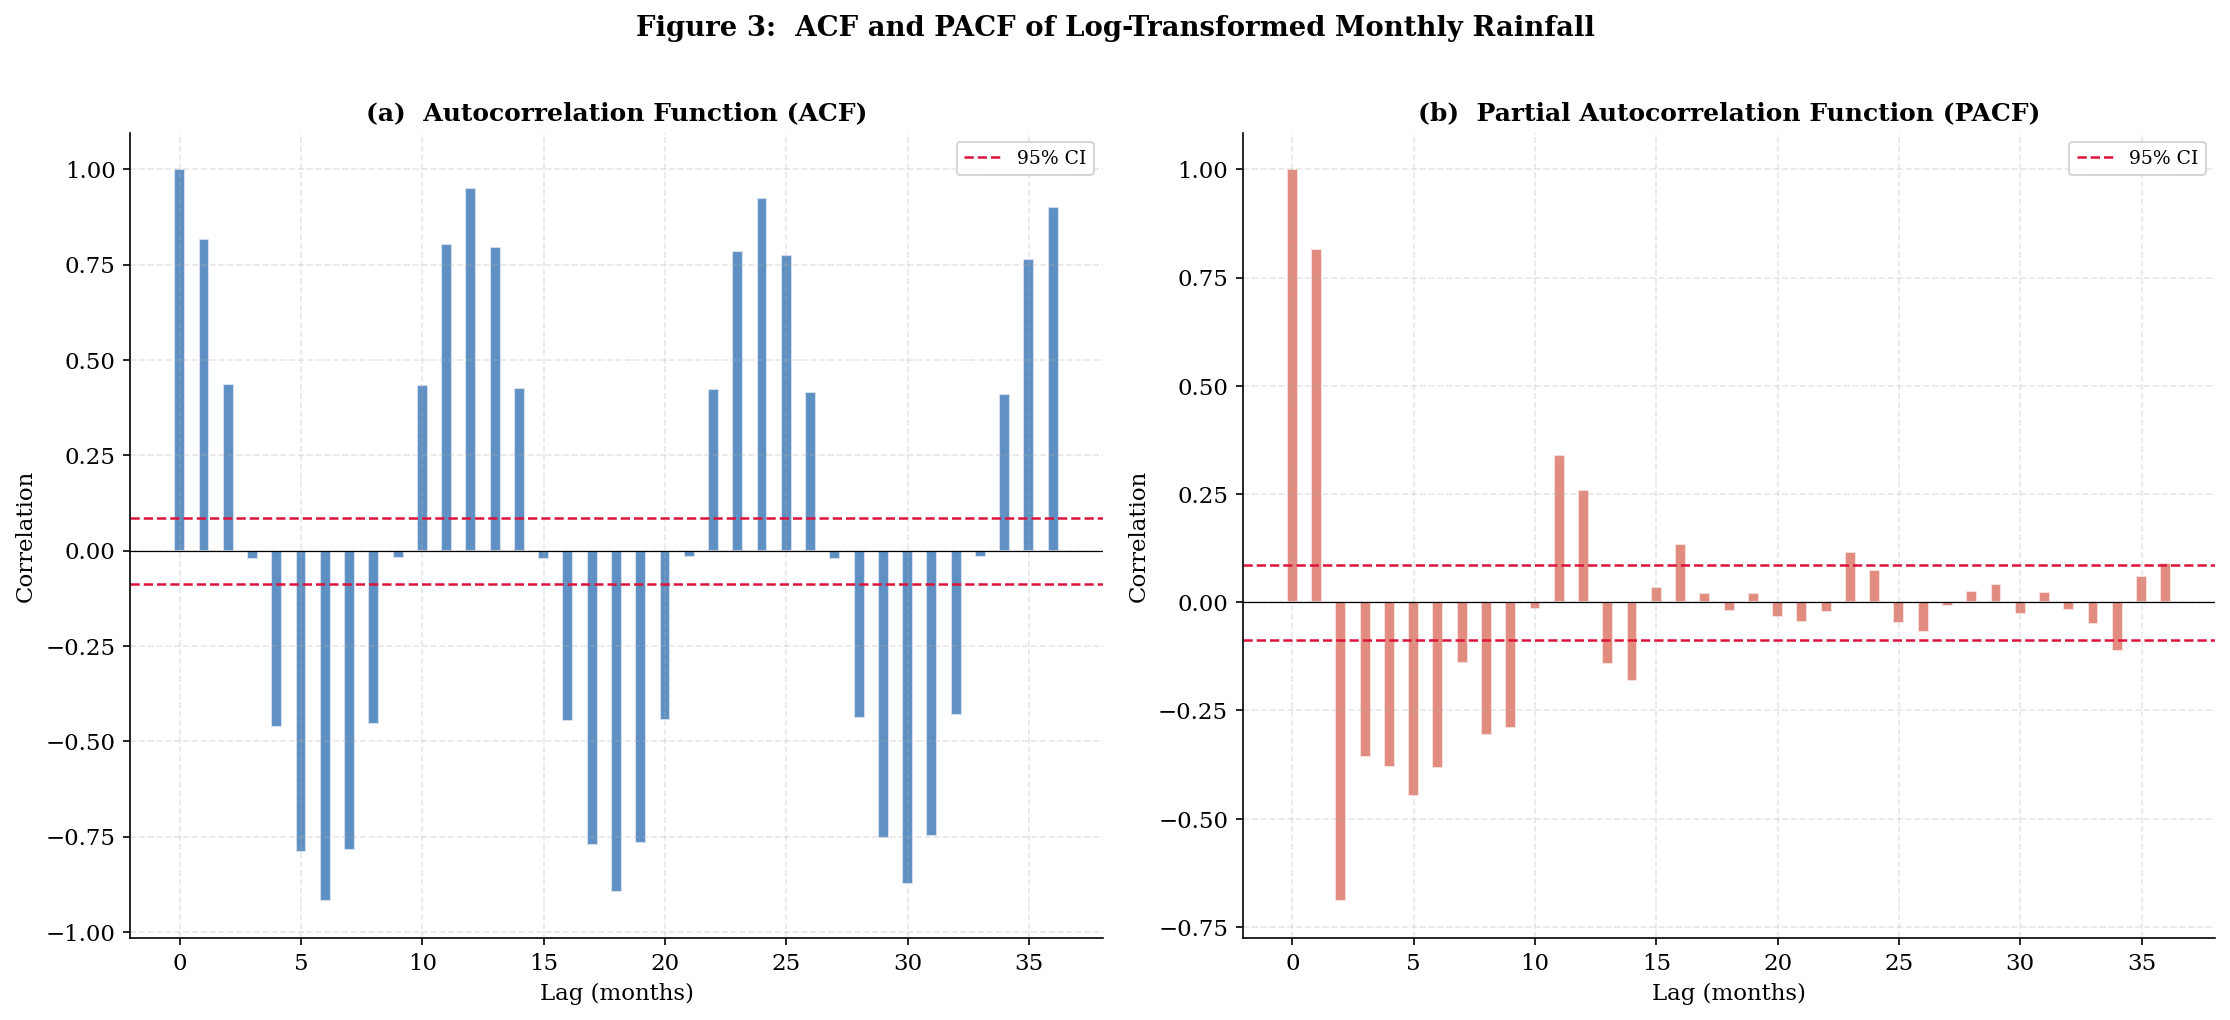

Figure 3 saved


In [10]:
from statsmodels.tsa.stattools import acf, pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 6.7))

nlags     = 36
acf_vals  = acf(log_series, nlags=nlags)
pacf_vals = pacf(log_series, nlags=nlags, method='ywm')
ci        = 1.96 / np.sqrt(len(log_series))

for ax, vals, title, col in zip(
    axes,
    [acf_vals, pacf_vals],
    ['(a)  Autocorrelation Function (ACF)',
     '(b)  Partial Autocorrelation Function (PACF)'],
    [C['sarima'], C['xgb']]
):
    ax.bar(range(len(vals)), vals,
           color=col, alpha=0.72,
           width=0.45, edgecolor='white')
    ax.axhline( ci, color='crimson', lw=1.2,
                ls='--', label='95% CI')
    ax.axhline(-ci, color='crimson', lw=1.2, ls='--')
    ax.axhline(0,   color='black',   lw=0.6)
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('Correlation')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle(
    'Figure 3:  ACF and PACF of Log-Transformed Monthly Rainfall',
    fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_acf_pacf.png', dpi=200)
plt.show()
print("Figure 3 saved")



*   the ACF plot exhibited pronounced seasonal peaks at lags 12, 24, and 36 months, indicating a strong annual seasonal pattern that required one seasonal difference.... so **D=1**
*   the PACF cuts off sharply after lag 1, supporting AR(1) non seasonal component.... so **p=1**



# Best SARIMA Model

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

# ── Load data
FILE = "Internship Updated Datasheet.xlsx"
monthly = pd.read_excel(FILE, sheet_name='Monthly_Data')
monthly.columns = ['Year','Month_No','Month','Season',
                   'Rainfall_mm','Log_Rain','ENSO','IOD','Split']
monthly['date'] = pd.to_datetime(
    monthly['Year'].astype(str) + '-' +
    monthly['Month_No'].astype(str).str.zfill(2) + '-01'
)
monthly    = monthly.set_index('date')
series     = monthly['Rainfall_mm']
log_series = monthly['Log_Rain']
TRAIN_END  = '2018-12'
TEST_START = '2019-01'
train      = log_series[:TRAIN_END]
test       = log_series[TEST_START:]
train_raw  = series[:TRAIN_END]
test_raw   = series[TEST_START:]

# ══════════════════════════════════════════════
# SARIMA ORDER SELECTION — ALL COMBINATIONS
# p, q, P, Q each from 0 to 2
# d=0 fixed (stationary confirmed)
# D=1 fixed (seasonal difference needed)
# s=12 fixed (annual period)
# ══════════════════════════════════════════════

q_values = [0, 1, 2, 3]
P_values = [0, 1, 2, 3]
Q_values = [0, 1, 2, 3]

p = 1
d = 0
D = 1
s = 12

# Generate ALL combinations
all_combinations = list(itertools.product(q_values, P_values, Q_values))

# Remove only the fully trivial model
valid_combinations = [
    (q, P, Q) for q, P, Q in all_combinations
    if not (q==0 and P==0 and Q==0)
]

total = len(valid_combinations)
print(f"Total SARIMA combinations to try: {total}")
print("Searching for best SARIMA order — please wait...\n")

best_aic            = np.inf
best_order          = None
best_seasonal_order = None
best_model          = None
results             = []
count               = 0
failed              = 0

for q, P, Q in valid_combinations:
    try:
        model = SARIMAX(
            train,
            order          = (p, d, q),
            seasonal_order = (P, D, Q, s),
            enforce_stationarity  = False,
            enforce_invertibility = False
        )
        fit = model.fit(disp=False, maxiter=300)

        results.append({
            'p': p, 'd': d, 'q': q,
            'P': P, 'D': D, 'Q': Q,
            'AIC': round(fit.aic, 2),
            'BIC': round(fit.bic, 2)
        })

        if fit.aic < best_aic:
            best_aic            = fit.aic
            best_order          = (p, d, q)
            best_seasonal_order = (P, D, Q, s)
            best_model          = fit

        count += 1

        if count % 10 == 0:
            print(f"  Fitted {count}/{total}"
                  f" | Failed: {failed}"
                  f" | Best AIC: {best_aic:.2f}"
                  f" | Best: SARIMA{best_order}"
                  f"{best_seasonal_order}")

    except Exception as e:
        failed += 1
        continue

# ── Results
print("\n" + "=" * 55)
print(f"Total fitted   : {count}")
print(f"Total failed   : {failed}")
print("=" * 55)

if not results:
    print("No models fitted successfully.")
else:
    results_df = pd.DataFrame(results).sort_values(
        'AIC').reset_index(drop=True)

    print("\n" + "=" * 55)
    print("SARIMA ORDER SELECTION COMPLETE")
    print("=" * 55)
    print(f"\nBest SARIMA Order    : {best_order}")
    print(f"Best Seasonal Order  : {best_seasonal_order}")
    print(f"Best AIC             : {best_aic:.2f}")
    print(f"Best BIC             : {best_model.bic:.2f}")

    print("\nTop 10 Models by AIC:")
    print(results_df.head(10)[
        ['p','d','q','P','D','Q','AIC','BIC']
    ].to_string(index=False))

    results_df.to_excel(
        'sarima_order_selection.xlsx',
        index=False
    )
    print("\nSaved to sarima_order_selection.xlsx")

    print("\n" + "=" * 55)
    print("BEST MODEL SUMMARY")
    print("=" * 55)
    print(f"  SARIMA order         : {best_order}")
    print(f"  Seasonal order       : {best_seasonal_order}")
    print(f"  AIC                  : {best_aic:.2f}")
    print(f"  BIC                  : {best_model.bic:.2f}")

    # ── Save for next cells
    sarima_fit   = best_model
    sarima_resid = sarima_fit.resid.dropna()
    print(f"\nResiduals extracted  : {len(sarima_resid)} months")
    print("sarima_fit ready for next cell.")

Total SARIMA combinations to try: 63
Searching for best SARIMA order — please wait...

  Fitted 10/63 | Failed: 0 | Best AIC: -132.95 | Best: SARIMA(1, 0, 0)(0, 1, 1, 12)
  Fitted 20/63 | Failed: 0 | Best AIC: -132.95 | Best: SARIMA(1, 0, 0)(0, 1, 1, 12)
  Fitted 30/63 | Failed: 0 | Best AIC: -132.95 | Best: SARIMA(1, 0, 0)(0, 1, 1, 12)
  Fitted 40/63 | Failed: 0 | Best AIC: -132.95 | Best: SARIMA(1, 0, 0)(0, 1, 1, 12)
  Fitted 50/63 | Failed: 0 | Best AIC: -132.95 | Best: SARIMA(1, 0, 0)(0, 1, 1, 12)
  Fitted 60/63 | Failed: 0 | Best AIC: -132.95 | Best: SARIMA(1, 0, 0)(0, 1, 1, 12)

Total fitted   : 63
Total failed   : 0

SARIMA ORDER SELECTION COMPLETE

Best SARIMA Order    : (1, 0, 0)
Best Seasonal Order  : (0, 1, 1, 12)
Best AIC             : -132.95
Best BIC             : -120.67

Top 10 Models by AIC:
 p  d  q  P  D  Q     AIC     BIC
 1  0  0  0  1  1 -132.95 -120.67
 1  0  1  0  1  1 -131.31 -114.94
 1  0  1  1  1  1 -127.86 -107.40
 1  0  2  0  1  1 -126.74 -106.29
 1  0  2  

# Table 2 and Fig 4 - Diagnostic Plot

Fitting SARIMA(1,0,0)(0,1,1)12 — please wait...

AIC : -132.95
BIC : -120.67

Parameter Table:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0255      0.044      0.584      0.559      -0.060       0.111
ma.S.L12      -1.1010      0.032    -34.590      0.000      -1.163      -1.039
sigma2         0.0342      0.003     13.528      0.000       0.029       0.039


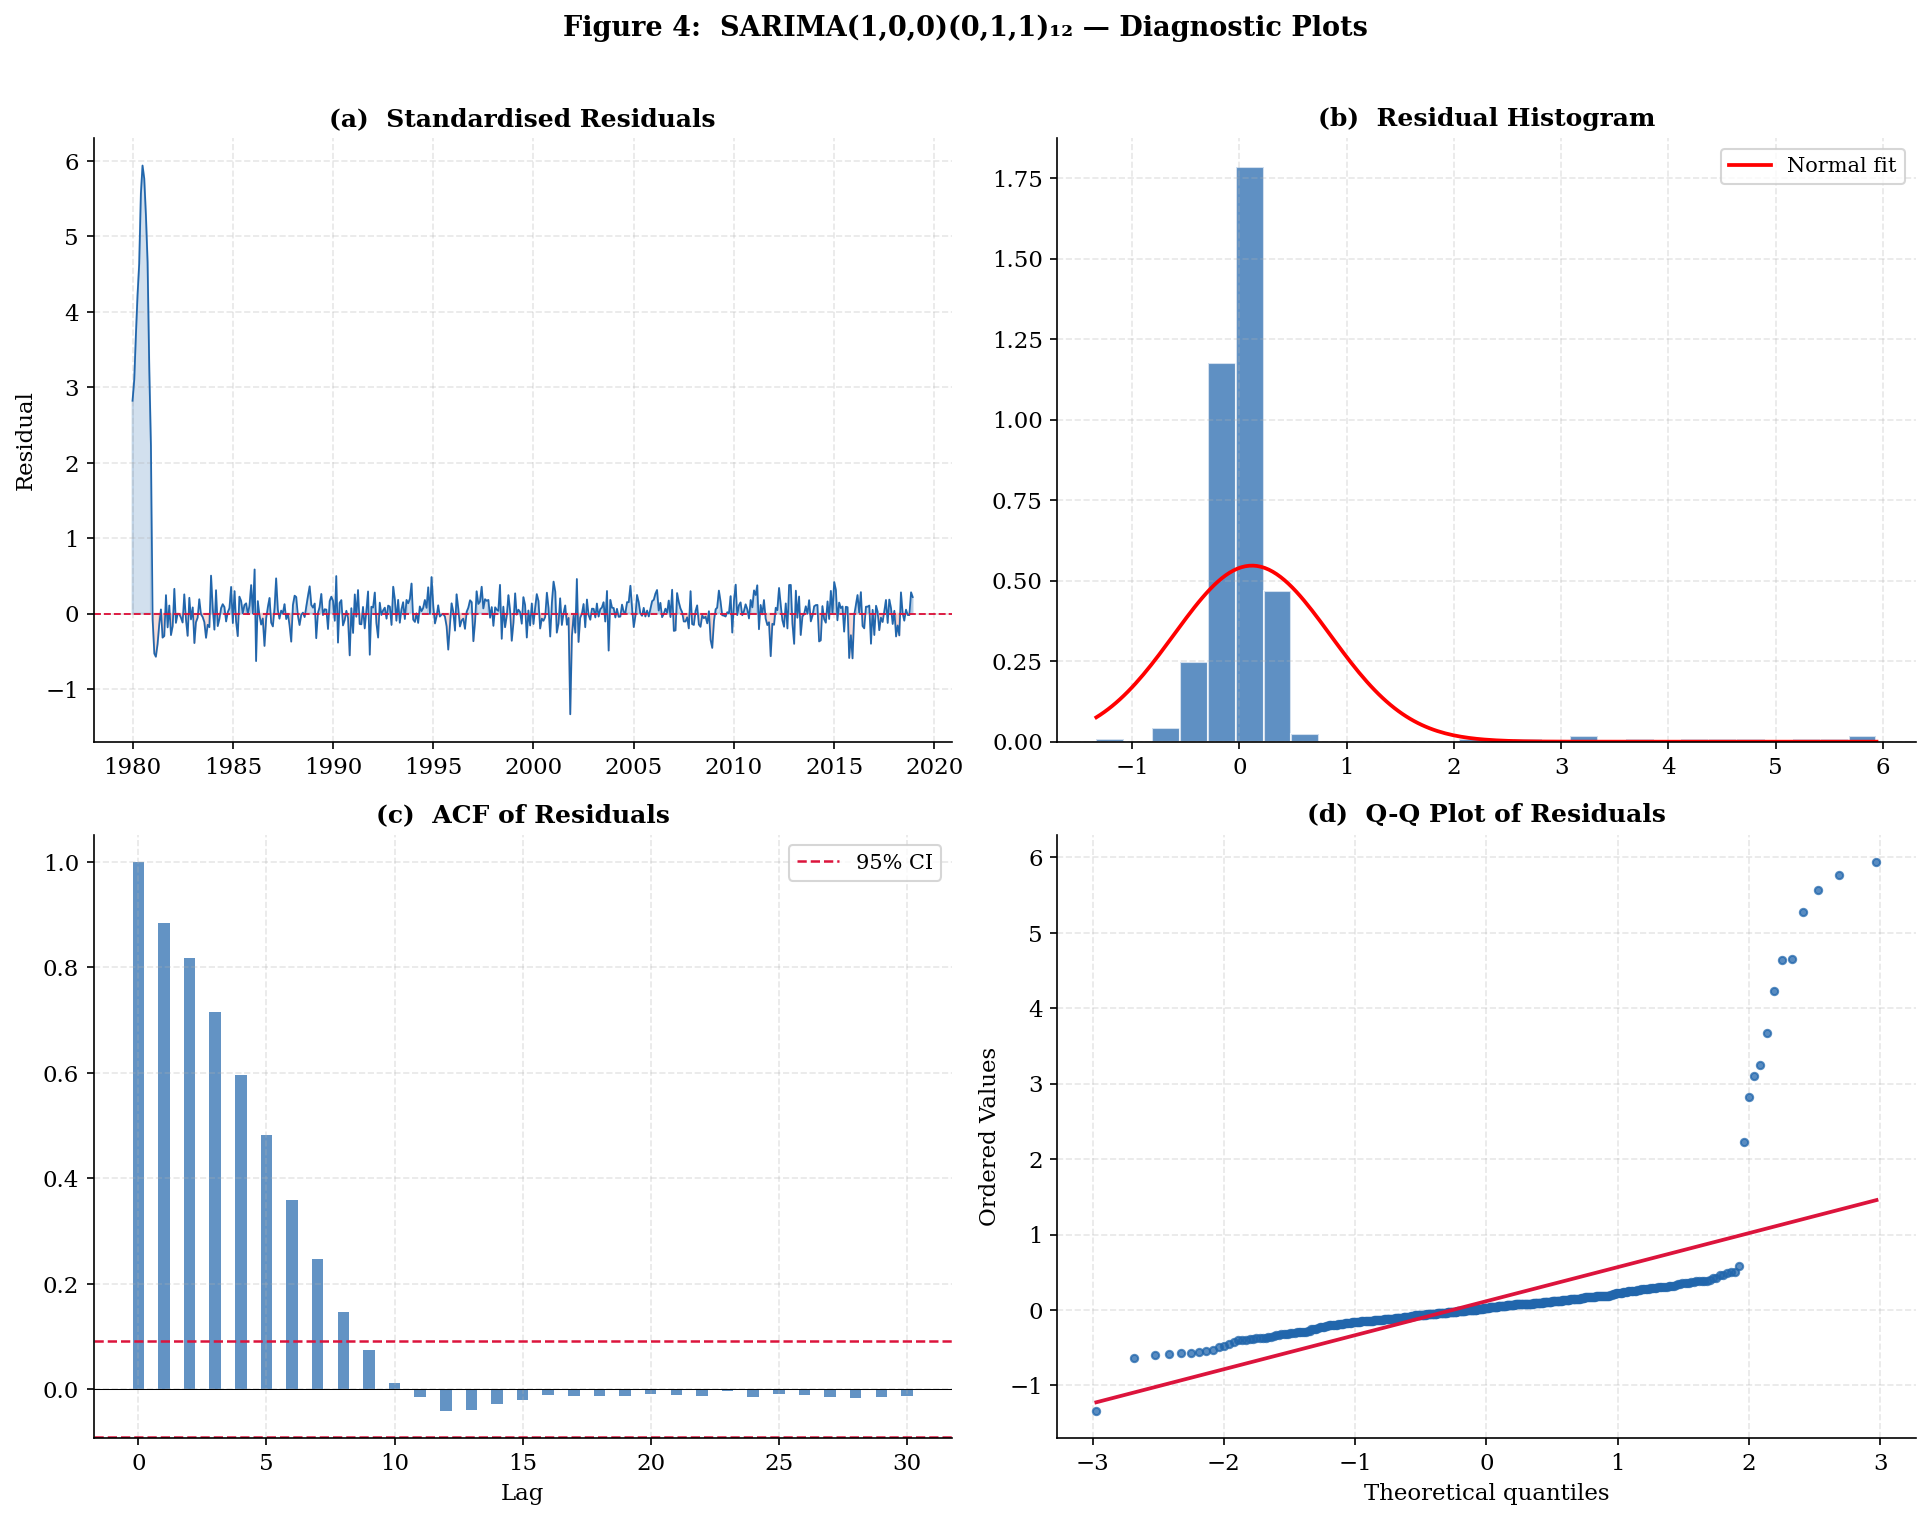

Figure 4 saved


In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf # Added this import
from scipy import stats

print("Fitting SARIMA(1,0,0)(0,1,1)12 — please wait...")

sarima_model = SARIMAX(train,
                        order=(1, 0, 0),
                        seasonal_order=(0, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False, maxiter=200)

print(f"\nAIC : {sarima_fit.aic:.2f}")
print(f"BIC : {sarima_fit.bic:.2f}")
print("\nParameter Table:")
print(sarima_fit.summary().tables[1])

sarima_resid = sarima_fit.resid.dropna()

# ── Figure 4 — Diagnostics
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0,0].plot(sarima_resid.index, sarima_resid.values,
               color=C['sarima'], lw=0.85)
axes[0,0].axhline(0, color='crimson', lw=0.9, ls='--')
axes[0,0].fill_between(sarima_resid.index,
                        sarima_resid.values, 0,
                        where=sarima_resid.values > 0,
                        color=C['sarima'], alpha=0.2)
axes[0,0].fill_between(sarima_resid.index,
                        sarima_resid.values, 0,
                        where=sarima_resid.values < 0,
                        color=C['xgb'], alpha=0.2)
axes[0,0].set_title('(a)  Standardised Residuals',
                     fontweight='bold')
axes[0,0].set_ylabel('Residual')

axes[0,1].hist(sarima_resid, bins=28,
               color=C['sarima'], alpha=0.72,
               edgecolor='white', density=True)
xrng = np.linspace(sarima_resid.min(),
                    sarima_resid.max(), 200)
axes[0,1].plot(xrng,
               stats.norm.pdf(xrng,
               sarima_resid.mean(), sarima_resid.std()),
               'r-', lw=1.8, label='Normal fit')
axes[0,1].set_title('(b)  Residual Histogram',
                     fontweight='bold')
axes[0,1].legend()

acf_r = acf(sarima_resid, nlags=30)
ci_r  = 1.96 / np.sqrt(len(sarima_resid))
axes[1,0].bar(range(len(acf_r)), acf_r,
              color=C['sarima'], alpha=0.7, width=0.45)
axes[1,0].axhline( ci_r, color='crimson',
                   lw=1.2, ls='--', label='95% CI')
axes[1,0].axhline(-ci_r, color='crimson', lw=1.2, ls='--')
axes[1,0].axhline(0, color='black', lw=0.5)
axes[1,0].set_title('(c)  ACF of Residuals', fontweight='bold')
axes[1,0].set_xlabel('Lag')
axes[1,0].legend()

stats.probplot(sarima_resid, dist='norm', plot=axes[1,1])
axes[1,1].set_title('(d)  Q-Q Plot of Residuals',
                     fontweight='bold')
axes[1,1].get_lines()[0].set(color=C['sarima'],
                              markersize=3.5, alpha=0.75)
axes[1,1].get_lines()[1].set(color='crimson', lw=1.8)

plt.suptitle(
    'Figure 4:  SARIMA(1,0,0)(0,1,1)₁₂ — Diagnostic Plots',
    fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig4_sarima_diag.png', dpi=200)
plt.show()
print("Figure 4 saved")

# Features Engineering - Only features using Lasso Regression

In [13]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

FILE = "Internship Updated Datasheet.xlsx"

# ── Load data
monthly = pd.read_excel(FILE, sheet_name='Monthly_Data')
monthly.columns = ['Year','Month_No','Month','Season',
                   'Rainfall_mm','Log_Rain','ENSO','IOD','Split']
monthly['date'] = pd.to_datetime(
    monthly['Year'].astype(str) + '-' +
    monthly['Month_No'].astype(str).str.zfill(2) + '-01'
)
monthly    = monthly.set_index('date')
series     = monthly['Rainfall_mm']
log_series = monthly['Log_Rain']
TRAIN_END  = '2018-12'
TEST_START = '2019-01'
train      = log_series[:TRAIN_END]
test       = log_series[TEST_START:]
train_raw  = series[:TRAIN_END]
test_raw   = series[TEST_START:]
train_df   = monthly[:TRAIN_END]
test_df    = monthly[TEST_START:]

# ══════════════════════════════════════════════
# STEP 1 — BUILD ALL CANDIDATE FEATURES
# Only from dataset columns — no new data
# Use log_rain not raw rainfall - both carry same property
# ══════════════════════════════════════════════
def build_all_features(df):
    F = pd.DataFrame(index=df.index)

    # Log rainfall lags — from Log_Rain column
    for k in [1, 2, 3, 6, 12, 24]:
        F[f'log_lag{k}'] = df['Log_Rain'].shift(k)

    # Cyclical month encoding — from Month_No column
    F['month_sin'] = np.sin(2 * np.pi * df['Month_No'] / 12)
    F['month_cos'] = np.cos(2 * np.pi * df['Month_No'] / 12)

    # Climate indices — directly from dataset
    F['enso'] = df['ENSO']
    F['iod']  = df['IOD']

    return F.dropna()

# ── Build candidate features on training data
X_candidates = build_all_features(train_df)
y_target     = log_series[:TRAIN_END].loc[X_candidates.index]

print("=" * 55)
print("CANDIDATE FEATURES BEFORE LASSO SELECTION")
print("=" * 55)
print(f"Shape          : {X_candidates.shape}")
print(f"Feature names  :")
for i, col in enumerate(X_candidates.columns, 1):
    print(f"  {i:>2}. {col}")

# ══════════════════════════════════════════════
# STEP 2 — LASSO REGRESSION FOR FEATURE SELECTION
# LassoCV automatically finds the best alpha
# Features with zero coefficient are removed
# ══════════════════════════════════════════════
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_candidates)

lasso_cv  = LassoCV(
    cv        = 5,
    max_iter  = 10000,
    random_state = 42
)
lasso_cv.fit(X_scaled, y_target)

# ── Get coefficients
coef_df = pd.DataFrame({
    'Feature'    : X_candidates.columns,
    'Coefficient': lasso_cv.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n" + "=" * 55)
print("LASSO COEFFICIENTS")
print("=" * 55)
print(f"Best alpha (regularisation): {lasso_cv.alpha_:.6f}")
print()
print(coef_df.to_string(index=False))

# ── Selected features — non-zero coefficients only
selected = coef_df[coef_df['Coefficient'] != 0]['Feature'].tolist()
removed  = coef_df[coef_df['Coefficient'] == 0]['Feature'].tolist()

print("\n" + "=" * 55)
print("SELECTED FEATURES — NON ZERO COEFFICIENT")
print("=" * 55)
for i, f in enumerate(selected, 1):
    coef = coef_df[coef_df['Feature']==f]['Coefficient'].values[0]
    print(f"  {i:>2}. {f:<20} coef = {coef:.6f}")

print("\n" + "=" * 55)
print("REMOVED FEATURES — ZERO COEFFICIENT")
print("=" * 55)
for f in removed:
    print(f"  Removed  {f}")

print(f"\nTotal selected : {len(selected)}")
print(f"Total removed  : {len(removed)}")

# ── Save selected feature names for next cell
SELECTED_FEATURES = selected
print(f"\nSelected features saved: {SELECTED_FEATURES}")

CANDIDATE FEATURES BEFORE LASSO SELECTION
Shape          : (444, 10)
Feature names  :
   1. log_lag1
   2. log_lag2
   3. log_lag3
   4. log_lag6
   5. log_lag12
   6. log_lag24
   7. month_sin
   8. month_cos
   9. enso
  10. iod

LASSO COEFFICIENTS
Best alpha (regularisation): 0.001167

  Feature  Coefficient
log_lag12     0.441579
log_lag24     0.357235
month_sin    -0.321814
month_cos    -0.262730
 log_lag2    -0.096872
 log_lag3    -0.064718
     enso    -0.045592
 log_lag1     0.041886
      iod     0.023040
 log_lag6    -0.000000

SELECTED FEATURES — NON ZERO COEFFICIENT
   1. log_lag12            coef = 0.441579
   2. log_lag24            coef = 0.357235
   3. month_sin            coef = -0.321814
   4. month_cos            coef = -0.262730
   5. log_lag2             coef = -0.096872
   6. log_lag3             coef = -0.064718
   7. enso                 coef = -0.045592
   8. log_lag1             coef = 0.041886
   9. iod                  coef = 0.023040

REMOVED FEATURES — ZER

# Features Engineering - Finalize the features

In [14]:
# ══════════════════════════════════════════════
# FEATURE ENGINEERING — SELECTED FEATURES ONLY
# Based on LASSO selection from previous cell
# Adding SARIMA residual lags on top
# ══════════════════════════════════════════════

def make_features(df, residuals=None):
    F = pd.DataFrame(index=df.index)

    # ── LASSO selected log rainfall lags
    for k in [1, 2, 3, 12, 24]:
        F[f'log_lag{k}'] = df['Log_Rain'].shift(k)

    # ── Cyclical month encoding
    F['month_sin'] = np.sin(2 * np.pi * df['Month_No'] / 12)
    F['month_cos'] = np.cos(2 * np.pi * df['Month_No'] / 12)

    # ── Climate indices from dataset
    F['enso'] = df['ENSO']
    F['iod']  = df['IOD']

    # ── SARIMA residual lags — if provided
    if residuals is not None:
        for k in [1, 2, 3]:
            F[f'resid_lag{k}'] = residuals.shift(k)

    return F.dropna()

# ── Test feature matrix
X_test = make_features(train_df)
print("=" * 55)
print("FINAL FEATURE MATRIX — WITHOUT RESIDUALS")
print("=" * 55)
print(f"Shape          : {X_test.shape}")
print(f"Total features : {X_test.shape[1]}")
print(f"\nFeature names:")
for i, col in enumerate(X_test.columns, 1):
    print(f"  {i:>2}. {col}")

FINAL FEATURE MATRIX — WITHOUT RESIDUALS
Shape          : (444, 9)
Total features : 9

Feature names:
   1. log_lag1
   2. log_lag2
   3. log_lag3
   4. log_lag12
   5. log_lag24
   6. month_sin
   7. month_cos
   8. enso
   9. iod


# Fit SARIMA model and extracting residuals

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# ── Fit best SARIMA model found earlier
# SARIMA(1,0,0)(0,1,1)12
print("Fitting SARIMA(1,0,0)(0,1,1)12 — please wait...")

sarima_model = SARIMAX(
    train,
    order          = (1, 0, 0),
    seasonal_order = (0, 1, 1, 12),
    enforce_stationarity  = False,
    enforce_invertibility = False
)
sarima_fit   = sarima_model.fit(disp=False, maxiter=300)
sarima_resid = sarima_fit.resid.dropna()

print(f"AIC : {sarima_fit.aic:.2f}")
print(f"BIC : {sarima_fit.bic:.2f}")
print(f"\nParameter Table:")
print(sarima_fit.summary().tables[1])
print(f"\nResiduals extracted: {len(sarima_resid)} months")

# ── Build full residual series for feature engineering
full_resid = pd.Series(np.nan, index=log_series.index)
full_resid[sarima_resid.index] = sarima_resid.values

# ── Build X_train and y_train WITH residuals
X_train = make_features(train_df, full_resid)
y_train = full_resid.loc[X_train.index].dropna()
X_train = X_train.loc[y_train.index]

print("\n" + "=" * 55)
print("TRAINING FEATURE MATRIX WITH RESIDUALS")
print("=" * 55)
print(f"X_train shape  : {X_train.shape}")
print(f"y_train shape  : {y_train.shape}")
print(f"\nAll features:")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i:>2}. {col}")

Fitting SARIMA(1,0,0)(0,1,1)12 — please wait...
AIC : -132.95
BIC : -120.67

Parameter Table:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0255      0.044      0.584      0.559      -0.060       0.111
ma.S.L12      -1.1010      0.032    -34.590      0.000      -1.163      -1.039
sigma2         0.0342      0.003     13.528      0.000       0.029       0.039

Residuals extracted: 468 months

TRAINING FEATURE MATRIX WITH RESIDUALS
X_train shape  : (444, 12)
y_train shape  : (444,)

All features:
   1. log_lag1
   2. log_lag2
   3. log_lag3
   4. log_lag12
   5. log_lag24
   6. month_sin
   7. month_cos
   8. enso
   9. iod
  10. resid_lag1
  11. resid_lag2
  12. resid_lag3




*   In train shape, there is 444 = (468-24) because of lag24



# Feature Matrix

In [16]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Re-load data and define train/test for standalone execution
FILE = "Internship Updated Datasheet.xlsx"
monthly = pd.read_excel(FILE, sheet_name='Monthly_Data')
monthly.columns = ['Year','Month_No','Month','Season',
                   'Rainfall_mm','Log_Rain','ENSO','IOD','Split']
monthly['date'] = pd.to_datetime(
    monthly['Year'].astype(str) + '-' +
    monthly['Month_No'].astype(str).str.zfill(2) + '-01'
)
monthly    = monthly.set_index('date')
series     = monthly['Rainfall_mm']
log_series = monthly['Log_Rain']
TRAIN_END  = '2018-12'
TEST_START = '2019-01'
train      = log_series[:TRAIN_END]
test       = log_series[TEST_START:]

# Re-fit SARIMA model to get sarima_resid, if not already available
sarima_model = SARIMAX(
    train,
    order          = (1, 0, 0),
    seasonal_order = (0, 1, 1, 12),
    enforce_stationarity  = False,
    enforce_invertibility = False
)
sarima_fit   = sarima_model.fit(disp=False, maxiter=300)
sarima_resid = sarima_fit.resid.dropna()


train_df = monthly[:TRAIN_END]
test_df  = monthly[TEST_START:]

# ── Full residual series
full_resid = pd.Series(np.nan, index=log_series.index)
full_resid[sarima_resid.index] = sarima_resid.values

# ══════════════════════════════════════════════
# BUILD FEATURE MATRICES
# ══════════════════════════════════════════════
def make_features(df, residuals=None):
    F = pd.DataFrame(index=df.index)

    for k in [1, 2, 3, 12, 24]:
        F[f'log_lag{k}'] = df['Log_Rain'].shift(k)

    F['month_sin'] = np.sin(
        2 * np.pi * df['Month_No'] / 12)
    F['month_cos'] = np.cos(
        2 * np.pi * df['Month_No'] / 12)

    F['enso'] = df['ENSO']
    F['iod']  = df['IOD']

    if residuals is not None:
        for k in [1, 2, 3]:
            F[f'resid_lag{k}'] = residuals.shift(k)

    return F.dropna()

# ── Training matrix
X_train = make_features(train_df, full_resid)
y_train = full_resid.loc[X_train.index].dropna()
X_train = X_train.loc[y_train.index]

# ── Test matrix
X_test  = make_features(test_df)

# ══════════════════════════════════════════════
# ADD LABELS FOR CLARITY
# ══════════════════════════════════════════════

# Training — add target and split label
train_matrix = X_train.copy()
train_matrix.insert(0, 'Date',
    X_train.index.strftime('%Y-%m'))
train_matrix['SARIMA_Residual'] = y_train.values
train_matrix['Split'] = 'Train'

# Test — add split label
test_matrix = X_test.copy()
test_matrix.insert(0, 'Date',
    X_test.index.strftime('%Y-%m'))
test_matrix['Split'] = 'Test'

# ══════════════════════════════════════════════
# SAVE TO EXCEL — 3 SHEETS
# ══════════════════════════════════════════════
with pd.ExcelWriter(
    'feature_matrix.xlsx',
    engine='openpyxl'
) as writer:

    # Sheet 1 — Training matrix with target
    train_matrix.to_excel(
        writer,
        sheet_name='Train_Feature_Matrix',
        index=False
    )

    # Sheet 2 — Test matrix
    test_matrix.to_excel(
        writer,
        sheet_name='Test_Feature_Matrix',
        index=False
    )

    # Sheet 3 — Combined full matrix
    # Training + Test together
    full_matrix = make_features(
        monthly, full_resid).copy()
    full_matrix.insert(0, 'Date',
        full_matrix.index.strftime('%Y-%m'))
    full_matrix['Split'] = [
        'Train' if d <= pd.Timestamp(TRAIN_END)
        else 'Test'
        for d in full_matrix.index
    ]
    full_matrix.to_excel(
        writer,
        sheet_name='Full_Feature_Matrix',
        index=False
    )

print("=" * 55)
print("FEATURE MATRIX SAVED")
print("=" * 55)
print(f"File           : feature_matrix.xlsx")
print(f"\nSheet 1 — Train_Feature_Matrix")
print(f"  Rows         : {len(train_matrix)}")
print(f"  Columns      : {len(train_matrix.columns)}")
print(f"  Features     : {X_train.shape[1]}")
print(f"  Target       : SARIMA_Residual")
print(f"\nSheet 2 — Test_Feature_Matrix")
print(f"  Rows         : {len(test_matrix)}")
print(f"  Columns      : {len(test_matrix.columns)}")
print(f"  Features     : {X_test.shape[1]}")
print(f"\nSheet 3 — Full_Feature_Matrix")
print(f"  Rows         : {len(full_matrix)}")
print(f"  Train + Test combined")
print(f"\nNote: Test matrix has 9 features")
print(f"Residual lags added after rolling SARIMA")

# ── Preview
print("\n" + "=" * 55)
print("TRAINING MATRIX — FIRST 5 ROWS")
print("=" * 55)
print(train_matrix.head().to_string(index=False))

print("\n" + "=" * 55)
print("TEST MATRIX — FIRST 5 ROWS")
print("=" * 55)
print(test_matrix.head().to_string(index=False))

# ── Download
from google.colab import files
files.download('feature_matrix.xlsx')

FEATURE MATRIX SAVED
File           : feature_matrix.xlsx

Sheet 1 — Train_Feature_Matrix
  Rows         : 444
  Columns      : 15
  Features     : 12
  Target       : SARIMA_Residual

Sheet 2 — Test_Feature_Matrix
  Rows         : 24
  Columns      : 11
  Features     : 9

Sheet 3 — Full_Feature_Matrix
  Rows         : 445
  Train + Test combined

Note: Test matrix has 9 features
Residual lags added after rolling SARIMA

TRAINING MATRIX — FIRST 5 ROWS
   Date  log_lag1  log_lag2  log_lag3  log_lag12  log_lag24  month_sin     month_cos  enso  iod  resid_lag1  resid_lag2  resid_lag3  SARIMA_Residual Split
1982-01    1.9846    3.4122    4.5517     2.7725     2.8219   0.500000  8.660254e-01   0.2  0.4   -0.284449    0.108498   -0.182660        -0.165222 Train
1982-02    2.6001    1.9846    3.4122     2.6077     3.1381   0.866025  5.000000e-01   0.2  0.4   -0.165222   -0.284449    0.108498         0.329540 Train
1982-03    3.1962    2.6001    1.9846     3.1306     3.7154   1.000000  6.1232

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Hyperparameter Tuning - For XGBoost



*   for only XGBoost, no residual is needed.



In [17]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import itertools
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════
# NO SARIMA HERE — fully independent XGBoost model
# ══════════════════════════════════════════════

def make_features(df):
    F = pd.DataFrame(index=df.index)
    for k in [1, 2, 3, 12, 24]:
        F[f'log_lag{k}'] = df['Log_Rain'].shift(k)
    F['month_sin'] = np.sin(2 * np.pi * df['Month_No'] / 12)
    F['month_cos'] = np.cos(2 * np.pi * df['Month_No'] / 12)
    F['enso'] = df['ENSO']
    F['iod']  = df['IOD']
    return F.dropna()

# ── Build features on FULL dataset, then slice to training period
X_full = make_features(monthly)
X_train = X_full.loc[:TRAIN_END]
y_train = log_series.loc[X_train.index]      # target = log rainfall, NOT residuals

print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")

# ══════════════════════════════════════════════
# HYPERPARAMETER GRID
# ══════════════════════════════════════════════
param_grid = {
    'n_estimators'    : [300, 500, 700],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.01, 0.03, 0.04, 0.05],
    'subsample'       : [0.70, 0.80, 0.90],
    'colsample_bytree': [0.70, 0.80, 0.90],
    'reg_alpha'       : [0.0, 0.10, 0.20],
    'reg_lambda'      : [0.50, 1.0, 1.50],
    'min_child_weight': [1, 2, 3],
}

tscv             = TimeSeriesSplit(n_splits=5)
keys             = list(param_grid.keys())
values_list      = list(param_grid.values())
all_combinations = list(itertools.product(*values_list))
total            = len(all_combinations)

print(f"\nTotal combinations : {total}")
print("Tuning started — please wait 20-30 mins...\n")

best_rmse   = np.inf
best_params = {}
results     = []

for idx, combo in enumerate(all_combinations):
    params  = dict(zip(keys, combo))
    cv_rmse = []

    for train_idx, val_idx in tscv.split(X_train):
        X_t = X_train.iloc[train_idx]
        y_t = y_train.iloc[train_idx]
        X_v = X_train.iloc[val_idx]
        y_v = y_train.iloc[val_idx]

        m = xgb.XGBRegressor(
            **params,
            random_state = 42,
            verbosity    = 0,
            objective    = 'reg:squarederror'
        )
        m.fit(X_t, y_t, verbose=False)
        pred      = m.predict(X_v)
        fold_rmse = np.sqrt(mean_squared_error(y_v, pred))
        cv_rmse.append(fold_rmse)

    avg_rmse = np.mean(cv_rmse)
    results.append({**params, 'avg_cv_rmse': round(avg_rmse, 6)})

    if avg_rmse < best_rmse:
        best_rmse   = avg_rmse
        best_params = params.copy()

    if (idx + 1) % 200 == 0:
        print(f"  {idx+1}/{total} done | Best RMSE: {best_rmse:.6f}")

# ── Results
results_df = pd.DataFrame(results).sort_values('avg_cv_rmse').reset_index(drop=True)

print("\n" + "=" * 55)
print("TUNING COMPLETE")
print("=" * 55)
print(f"Best CV RMSE : {best_rmse:.6f}")
print(f"\nBest Parameters:")
for k, v in best_params.items():
    print(f"  {k:<20} : {v}")

print("\nTop 5 combinations:")
print(results_df.head(5)[
    ['n_estimators', 'max_depth', 'learning_rate',
     'subsample', 'colsample_bytree', 'reg_alpha', 'min_child_weight',
     'avg_cv_rmse']
].to_string(index=False))

results_df.to_excel('hyperparameter_tuning_results.xlsx', index=False)
print("\nSaved to hyperparameter_tuning_results.xlsx")

print("\n" + "=" * 55)
print("TABLE A1 — COPY INTO YOUR REPORT")
print("=" * 55)
for k, v in best_params.items():
    print(f"  {k:<20} : {v}")
print(f"  {'random_state':<20} : 42")
print(f"  {'objective':<20} : reg:squarederror")
print(f"  {'Best CV RMSE':<20} : {best_rmse:.6f}")

X_train shape : (444, 9)
y_train shape : (444,)

Total combinations : 8748
Tuning started — please wait 20-30 mins...

  200/8748 done | Best RMSE: 0.242201
  400/8748 done | Best RMSE: 0.231120
  600/8748 done | Best RMSE: 0.231120
  800/8748 done | Best RMSE: 0.231120
  1000/8748 done | Best RMSE: 0.231120
  1200/8748 done | Best RMSE: 0.231120
  1400/8748 done | Best RMSE: 0.231120
  1600/8748 done | Best RMSE: 0.231120
  1800/8748 done | Best RMSE: 0.231120
  2000/8748 done | Best RMSE: 0.231120
  2200/8748 done | Best RMSE: 0.231120
  2400/8748 done | Best RMSE: 0.231120
  2600/8748 done | Best RMSE: 0.231120
  2800/8748 done | Best RMSE: 0.231120
  3000/8748 done | Best RMSE: 0.231120
  3200/8748 done | Best RMSE: 0.231120
  3400/8748 done | Best RMSE: 0.231120
  3600/8748 done | Best RMSE: 0.231120
  3800/8748 done | Best RMSE: 0.231120
  4000/8748 done | Best RMSE: 0.231120
  4200/8748 done | Best RMSE: 0.231120
  4400/8748 done | Best RMSE: 0.231120
  4600/8748 done | Best RMS

# Rolling SARIMA Forecast

In [ ]:
print("Rolling SARIMA forecast on test period — please wait...")

sar_preds_log = []
history       = list(train.values)

for i in range(len(test)):
    m = SARIMAX(history, order=sarima_fit.model.order, seasonal_order=sarima_fit.model.seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False)
    f = m.fit(disp=False, maxiter=300)
    sar_preds_log.append(f.forecast(1)[0])
    history.append(test.values[i])

sar_preds_log = np.array(sar_preds_log)
sar_preds_mm  = np.expm1(sar_preds_log)

print(f"SARIMA rolling forecast done — {len(sar_preds_log)} months predicted")

Rolling SARIMA forecast on test period — please wait...
SARIMA rolling forecast done — 48 months predicted


# XGBoost Fit and Predict

In [ ]:
xgb_model = xgb.XGBRegressor(**best_params, random_state=42, verbosity=0,
                              objective='reg:squarederror')
xgb_model.fit(X_train_xgb, y_train_xgb, verbose=False)
print("XGBoost model fitted")

xgb_preds_log = xgb_model.predict(X_test_xgb)
xgb_preds_mm  = np.expm1(xgb_preds_log)

print(f"XGBoost test predictions: {len(xgb_preds_mm)} months")

# ── SARIMA and XGBoost test length check
print(f"\nSARIMA test length  : {len(sar_preds_mm)}")
print(f"XGBoost test length : {len(xgb_preds_mm)}")

XGBoost model fitted
XGBoost test predictions: 48 months

SARIMA test length  : 48
XGBoost test length : 48


# SARIMA & XGBoost Test Length

In [ ]:
cidx = test.index.intersection(X_test_xgb.index)

sar_mm_a = pd.Series(sar_preds_mm, index=test.index).loc[cidx]
xgb_mm_a = pd.Series(xgb_preds_mm, index=X_test_xgb.index).loc[cidx]
y_test_a = test_raw.loc[cidx]

y_t   = y_test_a.values
sar_a = sar_mm_a.values
xgb_a = xgb_mm_a.values

clim_map = train_raw.groupby(train_raw.index.month).mean()
clim_a   = y_test_a.index.month.map(clim_map).values

print(f"Aligned test samples : {len(cidx)}")
print(f"y_t length           : {len(y_t)}")
print(f"sar_a length         : {len(sar_a)}")
print(f"xgb_a length         : {len(xgb_a)}")
print(f"clim_a length        : {len(clim_a)}")

Aligned test samples : 48
y_t length           : 48
sar_a length         : 48
xgb_a length         : 48
clim_a length        : 48


# Table 3 - Evaluation Matrix

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def rmse_(t, p):
    return np.sqrt(mean_squared_error(t, p))

def mae_(t, p):
    return mean_absolute_error(t, p)

def mape_(t, p):
    m = t > 0
    return 100 * np.mean(np.abs((t[m] - p[m]) / t[m]))

def nse_(t, p):
    return 1 - np.sum((t - p)**2) / np.sum((t - t.mean())**2)

def skill_(t, p, ref_rmse):
    return 1 - rmse_(t, p) / ref_rmse



models_eval = {
    'SARIMA(1,0,0)(0,1,1)12' : sar_a,
    'XGBoost'                : xgb_a
}

rows = []
for name, pred in models_eval.items():
    rows.append({
        'Model'      : name,
        'RMSE (mm)'  : round(rmse_(y_t, pred), 4),
        'MAE (mm)'   : round(mae_(y_t, pred), 4),
        'MAPE (%)'   : round(mape_(y_t, pred), 4),
        'NSE'        : round(nse_(y_t, pred), 4),
        'Skill Score': round(skill_(y_t, pred, clim_rmse), 4)
    })

met_df = pd.DataFrame(rows)
print("=" * 60)
print("TABLE 3 — EVALUATION METRICS")
print("=" * 60)
print(met_df.to_string(index=False))

TABLE 3 — EVALUATION METRICS
                 Model  RMSE (mm)  MAE (mm)  MAPE (%)    NSE  Skill Score
SARIMA(1,0,0)(0,1,1)12    21.6335   15.1412   16.9382 0.9692      -0.0195
               XGBoost    25.8877   17.5317   16.9504 0.9558      -0.2199


# Fig 5 - Observed vs Predicted

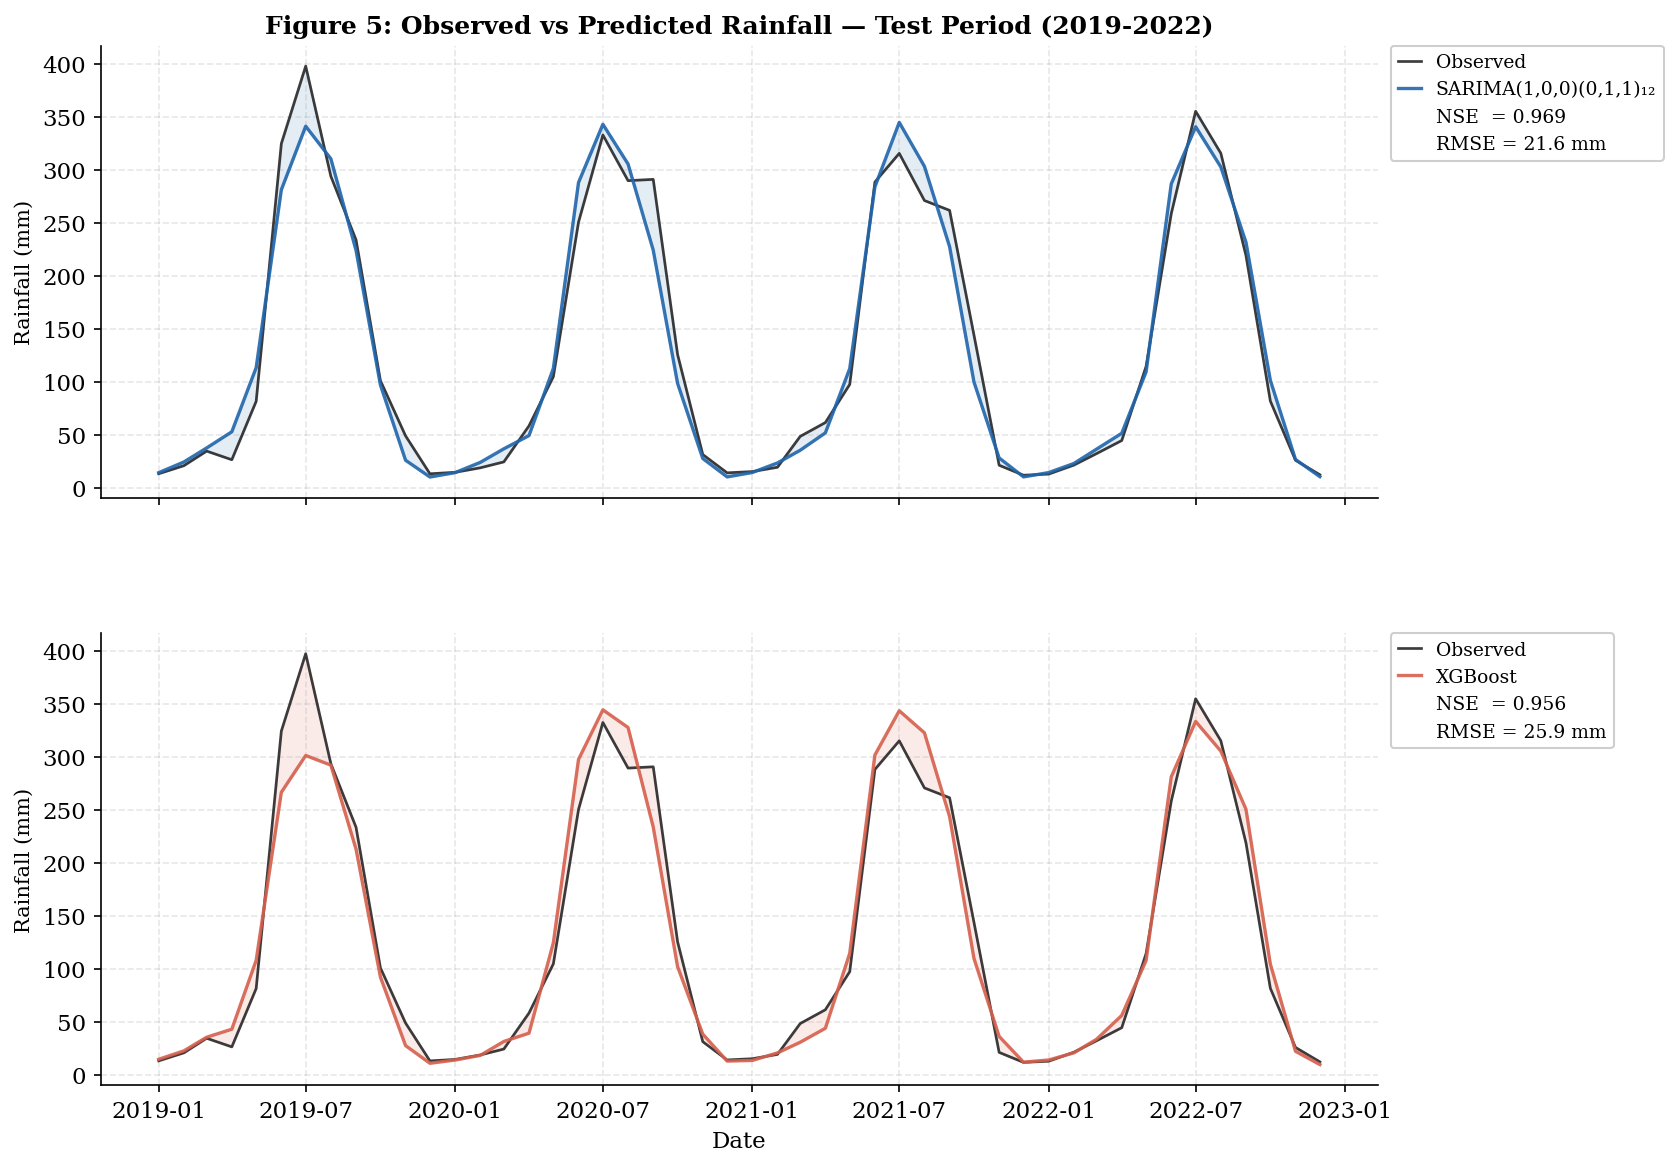

Figure 5 saved


In [ ]:
import matplotlib.pyplot as plt

C = {'sarima': '#2166ac', 'xgb': '#d6604d', 'actual': '#222222'}

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

preds_list = [
    ('SARIMA(1,0,0)(0,1,1)₁₂', sar_a, C['sarima'], '-'),
    ('XGBoost',                 xgb_a, C['xgb'],    '-'),
]

for ax, (name, pred, col, ls) in zip(axes, preds_list):
    line_obs,  = ax.plot(cidx, y_t, color=C['actual'],
                          lw=1.3, label='Observed', alpha=0.88)
    line_pred, = ax.plot(cidx, pred, color=col,
                          lw=1.6, ls=ls, label=name, alpha=0.9)
    ax.fill_between(cidx, y_t, pred, alpha=0.12, color=col)

    nse_v  = nse_(y_t, pred)
    rmse_v = rmse_(y_t, pred)
    nse_line  = plt.Line2D([], [], color='none', label=f'NSE  = {nse_v:.3f}')
    rmse_line = plt.Line2D([], [], color='none', label=f'RMSE = {rmse_v:.1f} mm')

    ax.set_ylabel('Rainfall (mm)', fontsize=10)
    ax.legend(handles=[line_obs, line_pred, nse_line, rmse_line],
              framealpha=0.95, fontsize=9,
              loc='upper left', bbox_to_anchor=(1.01, 1),
              borderaxespad=0, handlelength=1.2)

axes[0].set_title('Figure 5: Observed vs Predicted Rainfall — Test Period (2019-2022)',
                   fontweight='bold', fontsize=12)
axes[-1].set_xlabel('Date')
plt.subplots_adjust(right=0.78, hspace=0.30)
plt.savefig('fig5_predictions.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 5 saved")

# Fig 6 - Feature Importance

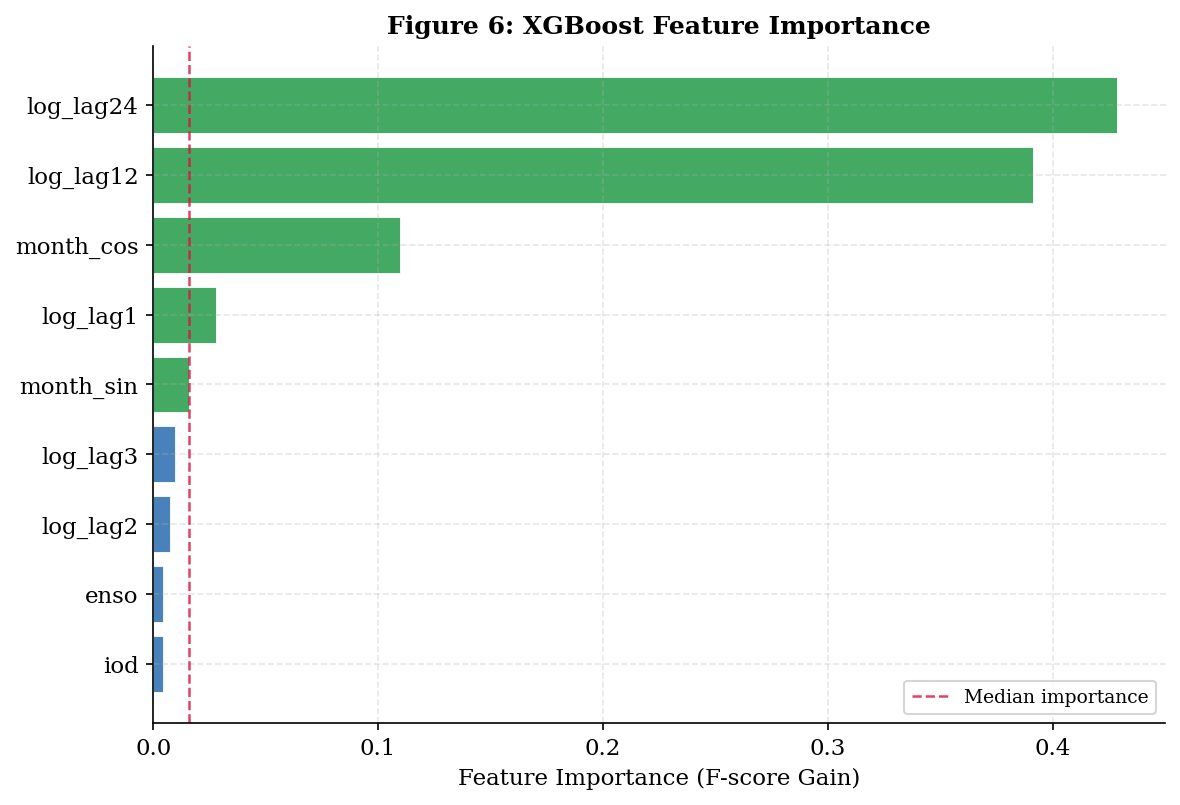

Figure 6 saved


In [ ]:
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X_train_xgb.columns
).sort_values()

colors_fi = ['#1a9641' if v >= feat_imp.median() else '#2166ac'
             for v in feat_imp.values]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(feat_imp.index, feat_imp.values,
        color=colors_fi, alpha=0.82, edgecolor='white', lw=0.5)
ax.axvline(feat_imp.median(), color='crimson', lw=1.2,
           ls='--', alpha=0.8, label='Median importance')
ax.set_xlabel('Feature Importance (F-score Gain)')
ax.set_title('Figure 6: XGBoost Feature Importance', fontweight='bold', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('fig6_feat_importance.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 6 saved")

**What it shows:**

Among the nine LASSO-selected features, log_lag24 (≈0.43 gain) and log_lag12 (≈0.39 gain) dominate completely, together accounting for roughly 82% of total model gain. month_cos contributes a distant third (≈0.11), while log_lag1, month_sin, log_lag3, log_lag2, enso, and iod all fall below the median importance line and contribute only marginally.

**Why this happens:**

The underlying rainfall series repeats an almost deterministic seasonal cycle every year — July is reliably the wettest month, December reliably the driest, year after year (Section 2.4/4.1). Because of this near-exact annual repetition, "what did this calendar month look like 12 months ago" and "what did it look like 24 months ago" are extremely strong, almost direct proxies for "what will this calendar month look like now." XGBoost, when given the choice, exploits this: it has essentially discovered the seasonal cycle empirically through the 12- and 24-month lags rather than needing to learn it any other way. This is exactly consistent with the LASSO coefficients (Table 4), where log_lag12 and log_lag24 also carry the two largest absolute coefficients — both methods independently point to the same structural signal.

Why month_cos/month_sin still matter, but less: These cyclical encodings directly represent calendar position without relying on historical values at all. They pick up residual seasonal signal not already captured by the lags — useful, but secondary, since the lags already do most of that job.

Why enso and iod rank lowest, but aren't zero: ENSO and IOD don't set the seasonal baseline — they modulate the amplitude of a given monsoon around that baseline (an El Niño year suppresses it, a La Niña year enhances it). Since the baseline itself is already well captured by the lag features, the climate indices are left to explain only the smaller, secondary year-to-year deviations — hence their small but non-zero importance. That they aren't exactly zero is actually a meaningful check: a genuinely useless predictor would typically get shrunk to indistinguishable-from-zero importance.

# Fig 7 - Residual Analysis — SARIMA & XGBoost

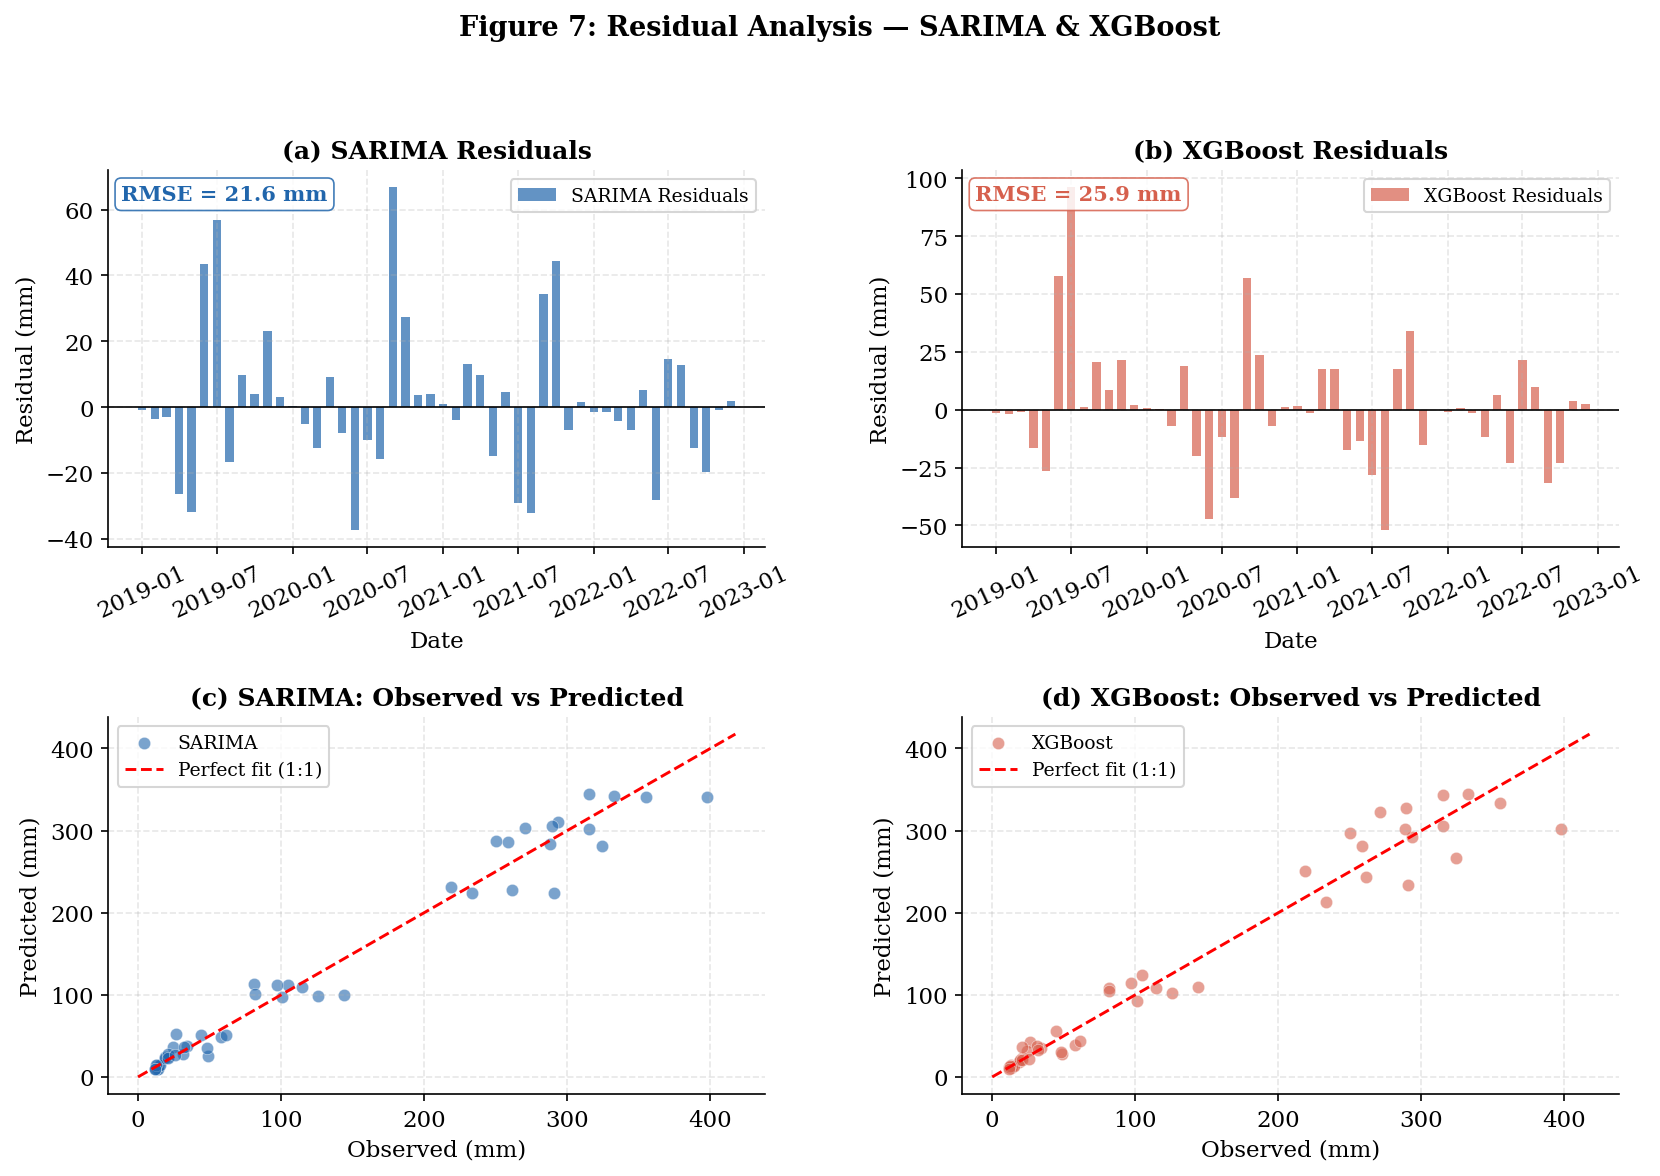

Figure 7 saved


In [ ]:
res_sar = y_t - sar_a
res_xgb = y_t - xgb_a

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for col, (res, name, color) in enumerate(
        [(res_sar, 'SARIMA', C['sarima']),
         (res_xgb, 'XGBoost', C['xgb'])]):

    ax = axes[0, col]
    ax.bar(cidx, res, color=color, alpha=0.70, width=20,
           label=f'{name} Residuals')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel('Residual (mm)')
    ax.set_xlabel('Date')
    ax.set_title(f'({chr(97+col)}) {name} Residuals', fontweight='bold')
    rmse_v = np.sqrt(np.mean(res**2))
    ax.text(0.02, 0.92, f'RMSE = {rmse_v:.1f} mm',
            transform=ax.transAxes, fontsize=10, color=color,
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      alpha=0.85, edgecolor=color, lw=0.8))
    ax.legend(loc='upper right', fontsize=9)
    ax.tick_params(axis='x', rotation=25)

    ax2 = axes[1, col]
    pred = y_t - res
    ax2.scatter(y_t, pred, color=color, alpha=0.60, s=35,
                edgecolors='white', lw=0.3, label=name)
    lim = [0, max(y_t.max(), pred.max()) + 20]
    ax2.plot(lim, lim, 'r--', lw=1.4, label='Perfect fit (1:1)')
    ax2.set_xlabel('Observed (mm)')
    ax2.set_ylabel('Predicted (mm)')
    ax2.set_title(f'({chr(99+col)}) {name}: Observed vs Predicted', fontweight='bold')
    ax2.legend(fontsize=9)

plt.suptitle('Figure 7: Residual Analysis — SARIMA & XGBoost',
              fontweight='bold', fontsize=13, y=1.01)
plt.subplots_adjust(hspace=0.45, wspace=0.30)
plt.savefig('fig7_residuals.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 7 saved")

# Fig 8 - Model Comparison

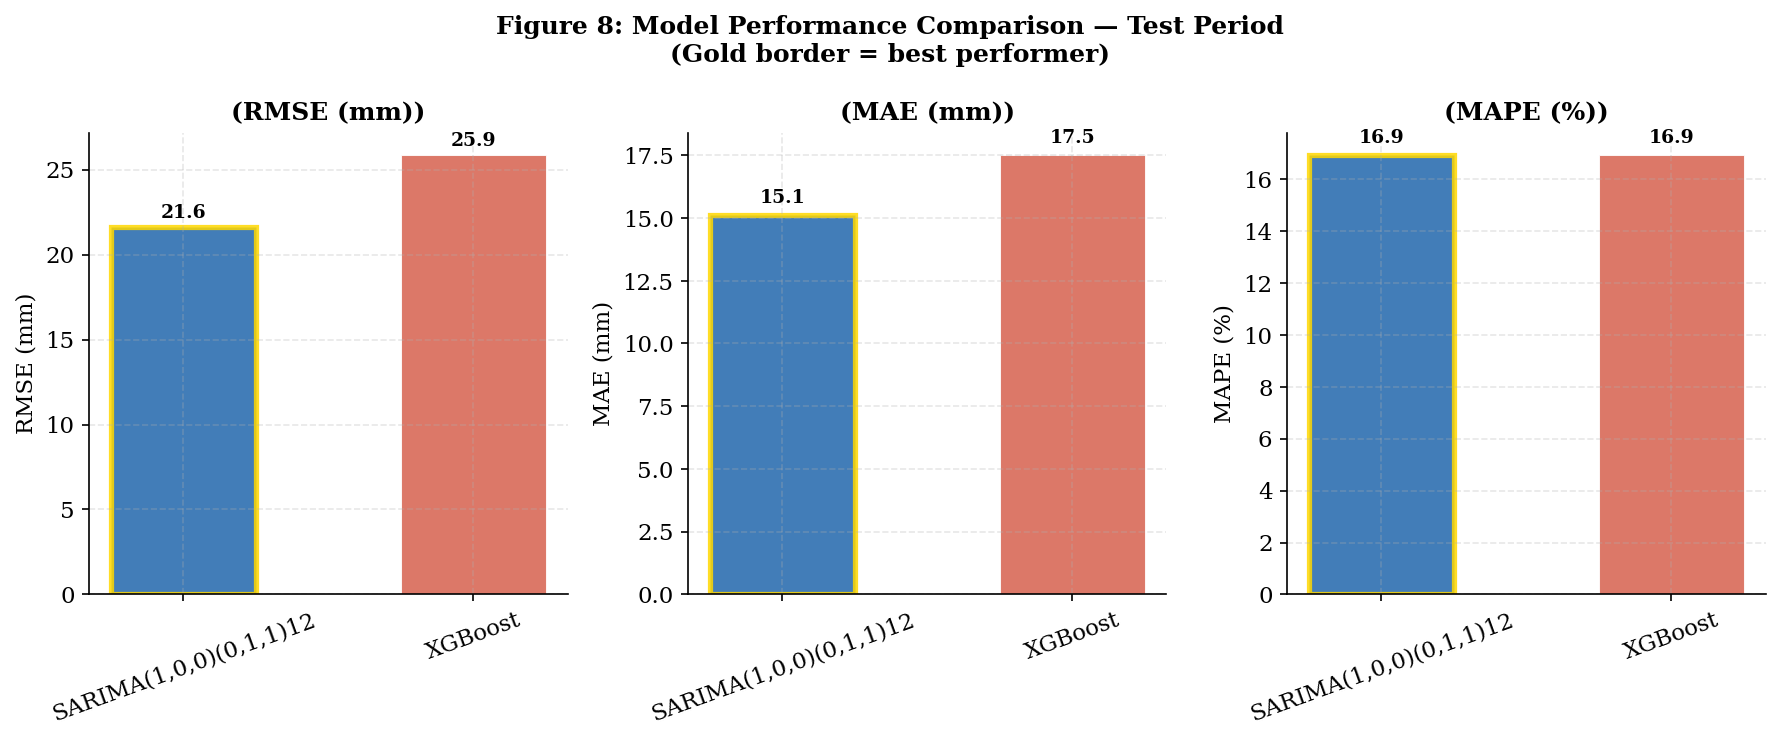


FINAL TABLE 3
                 Model  RMSE (mm)  MAE (mm)  MAPE (%)    NSE  Skill Score
SARIMA(1,0,0)(0,1,1)12      21.63     15.14     16.94 0.9692      -0.0195
               XGBoost      25.89     17.53     16.95 0.9558      -0.2199

Figure 8 saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
bar_c = [C['sarima'], C['xgb']]

for ax, metric in zip(axes, ['RMSE (mm)', 'MAE (mm)', 'MAPE (%)']):
    vals = met_df[metric].values
    bs   = ax.bar(met_df['Model'], vals, color=bar_c,
                  alpha=0.85, edgecolor='white', lw=0.5, width=0.5)
    ax.set_title(f'({metric})', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)

    for b, v in zip(bs, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

    best_i = np.argmin(vals)
    bs[best_i].set_edgecolor('gold')
    bs[best_i].set_linewidth(2.5)

plt.suptitle('Figure 8: Model Performance Comparison — Test Period\n'
             '(Gold border = best performer)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('fig8_metrics.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("FINAL TABLE 3")
print("=" * 60)
print(met_df.to_string(index=False))
print("\nFigure 8 saved")

In [ ]:
from google.colab import files

file_list = [
    'fig1a_timeseries.png', 'fig1b_climatology.png', 'fig1c_jjas_bargraph.png',
    'decomposition_dataset.xlsx', 'fig2_decomp.png', 'fig3_acf_pacf.png',
    'sarima_order_selection.xlsx', 'fig4_sarima_diag.png',
    'feature_matrix.xlsx', 'hyperparameter_tuning_results.xlsx',
    'fig5_predictions.png', 'fig6_feat_importance.png',
    'fig7_residuals.png', 'fig8_metrics.png'
]

for f in file_list:
    try:
        files.download(f)
        print(f"Downloaded: {f}")
    except:
        print(f"Not found: {f}")

print("\nAll files downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: fig1a_timeseries.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: fig7_residuals.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: fig8_metrics.png

All files downloaded.
